In [1]:
# Project setup
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

from src.data.loaders import PointsDataset
from src.visualization.visualization_utils import create_meshgrid
from src.visualization.feature_space_plots import plot_in_rectangular_coordinates, PlotManager
from src.data.synthetic import generate_custom_polar_dataset
from src.features.transformations import cartesian_to_polar, polar_to_curvilinear_r2cos2theta, polar_to_cartesian

from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.linear_model import LogisticRegression
from src.evaluation.metrics import ModelMetrics
from src.models.model_utilities import Model1DWrapper
from sklearn.svm import SVC

In [3]:
random_state = 42

current_dir = Path.cwd()

PLOT_CONFIG = {
    "show": True,
    "save": True,
    "out_dir": current_dir.parent / "results" / "figures"
}

plot_manager = PlotManager(PLOT_CONFIG)

# Dataset Sample with Noise

In [4]:
r_cutoff = 1.0
r_max = 2 * r_cutoff
theta_kappa = 1000
r_noise = 0.1
num_class_points = 80

In [5]:
synth_polar_pos_dataset = generate_custom_polar_dataset(
    label=1,
    num_points=num_class_points,
    theta_noise=theta_kappa,
    r_noise=r_noise,
    r_outer_bound_func=lambda theta: np.array([r_cutoff]*theta.size),
    random_seed=random_state
)

synth_polar_neg_dataset = generate_custom_polar_dataset(
    label=0,
    num_points=num_class_points,
    r_inner_bound_func=lambda theta: np.array([r_cutoff]*theta.size),
    r_outer_bound_func=lambda theta: np.array([r_max]*theta.size),
    theta_noise=theta_kappa,
    r_noise=r_noise,
    random_seed=random_state
)

synth_polar_dataset = PointsDataset.merge_dataset(synth_polar_pos_dataset, synth_polar_neg_dataset)
synth_cartesian_dataset = synth_polar_dataset.transform(polar_to_cartesian)
synth_r2cos2_dataset = synth_polar_dataset.transform(polar_to_curvilinear_r2cos2theta)

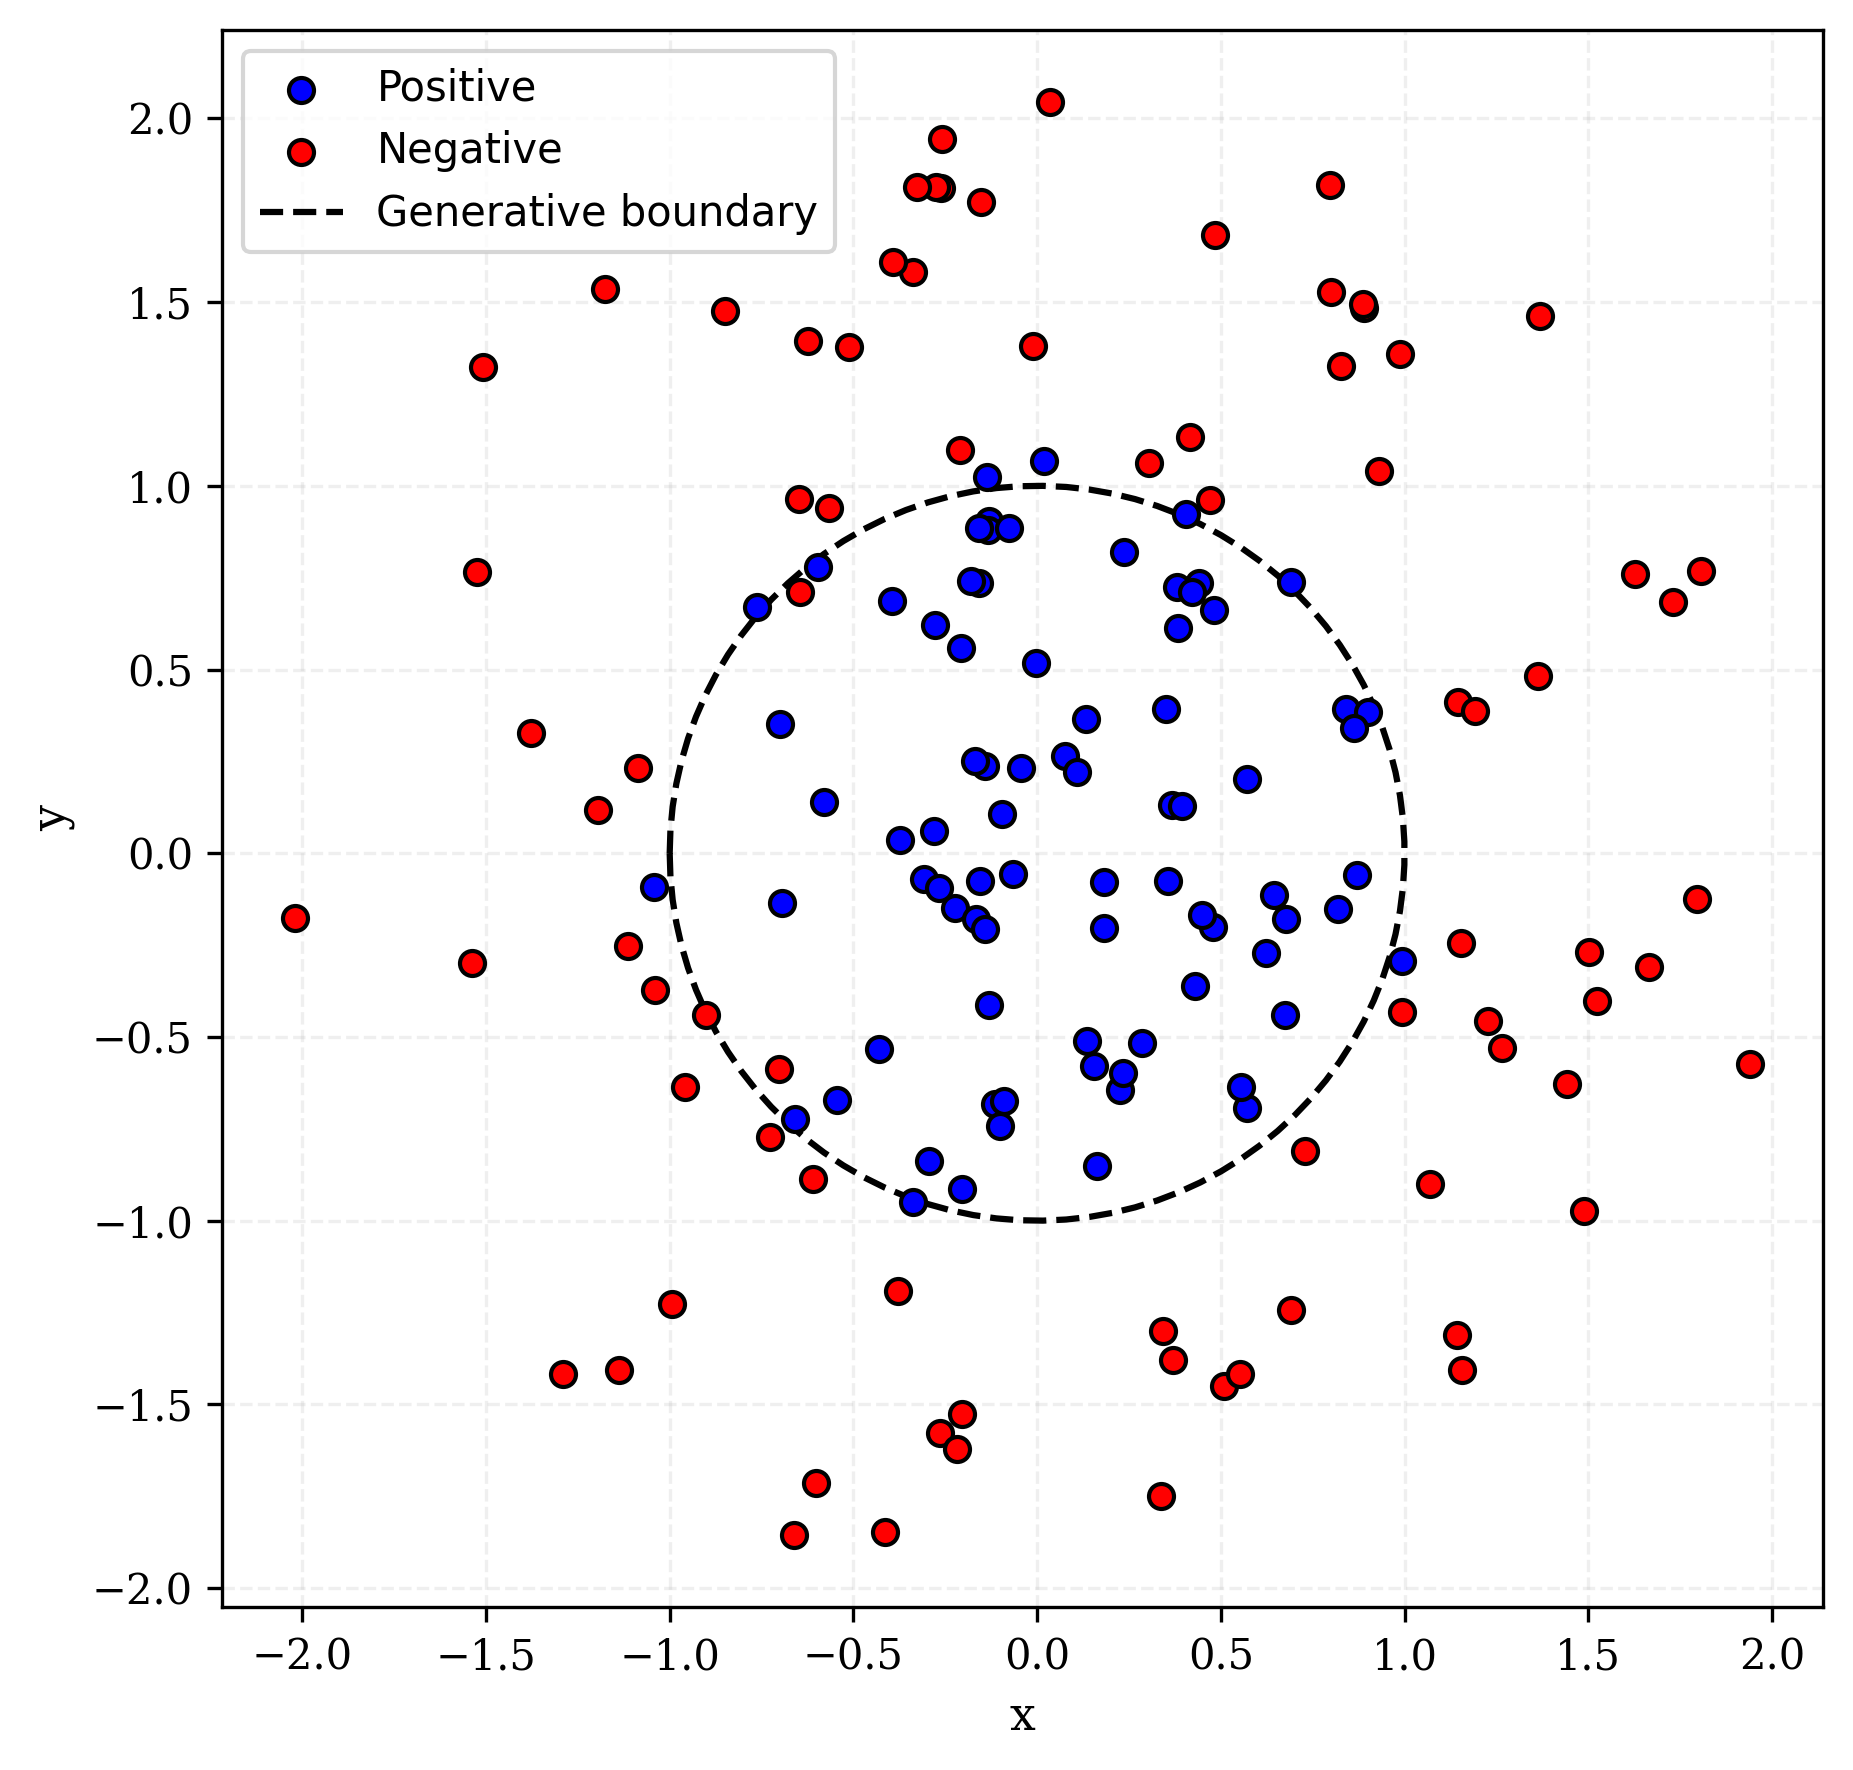

In [6]:
sample_fig, sample_ax = plot_in_rectangular_coordinates(
    synth_cartesian_dataset.X, 
    synth_cartesian_dataset.y,
    axis_x_label = 'x', axis_y_label = 'y',
    title=""
)

Thetas = np.linspace(-np.pi, np.pi, 100)
sample_ax.plot(r_cutoff*np.cos(Thetas), r_cutoff*np.sin(Thetas), color='black', linestyle='--', label='Generative boundary')
sample_ax.legend()
sample_ax.set_aspect('equal')

display(sample_fig)

In [7]:
plot_manager.handle(sample_fig, name='sample_synthetic_dataset')

In [8]:
TP_ref = len(synth_polar_dataset.X[(synth_polar_dataset.X['r']<=r_cutoff) & (synth_polar_dataset.y==1)])
TN_ref = len(synth_polar_dataset.X[(synth_polar_dataset.X['r']>r_cutoff) & (synth_polar_dataset.y==0)])

reference_metrics = {
    'accuracy': (TP_ref + TN_ref)/(2*num_class_points),
    'precision': TP_ref/(TP_ref + (num_class_points-TN_ref)),
    'recall': TP_ref/(num_class_points)
}
reference_metrics['f1'] = 2 * (reference_metrics['precision'] * reference_metrics['recall']) / (reference_metrics['precision'] + reference_metrics['recall'])
metrics_df = pd.DataFrame(reference_metrics, index=['Generator decision boundary'])
display(metrics_df)

,accuracy,precision,recall,f1
Generator decision boundary,0.9375,0.972973,0.9,0.935065


## Decision Boundaries

In [9]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(x1=synth_cartesian_dataset.X['x'], x2=synth_cartesian_dataset.X['y'], resolution=500)
grid_cartesian = grid_cartesian.rename(columns={'x1': 'x', 'x2': 'y'})

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_cartesian)

# Transform polar into curvilinear grid
grid_r2cos2_sqd = pd.DataFrame({'r^2': grid_polar['r']**2, 'cos^2()': np.cos(grid_polar['theta'])**2})

### Logistic

In [10]:
lr_model = LogisticRegression(random_state=random_state)
lr_model.fit(synth_polar_dataset.X, synth_polar_dataset.y)
lr_metrics = ModelMetrics('Logistic Regression', 'Polar', synth_polar_dataset.y, lr_model.predict(synth_polar_dataset.X))
lr_metrics.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metrics.to_pandas().rename(index={0:'Logistic Regression | Polar'})])

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Circular Polar',
    metrics=lr_metrics.to_dict()
)

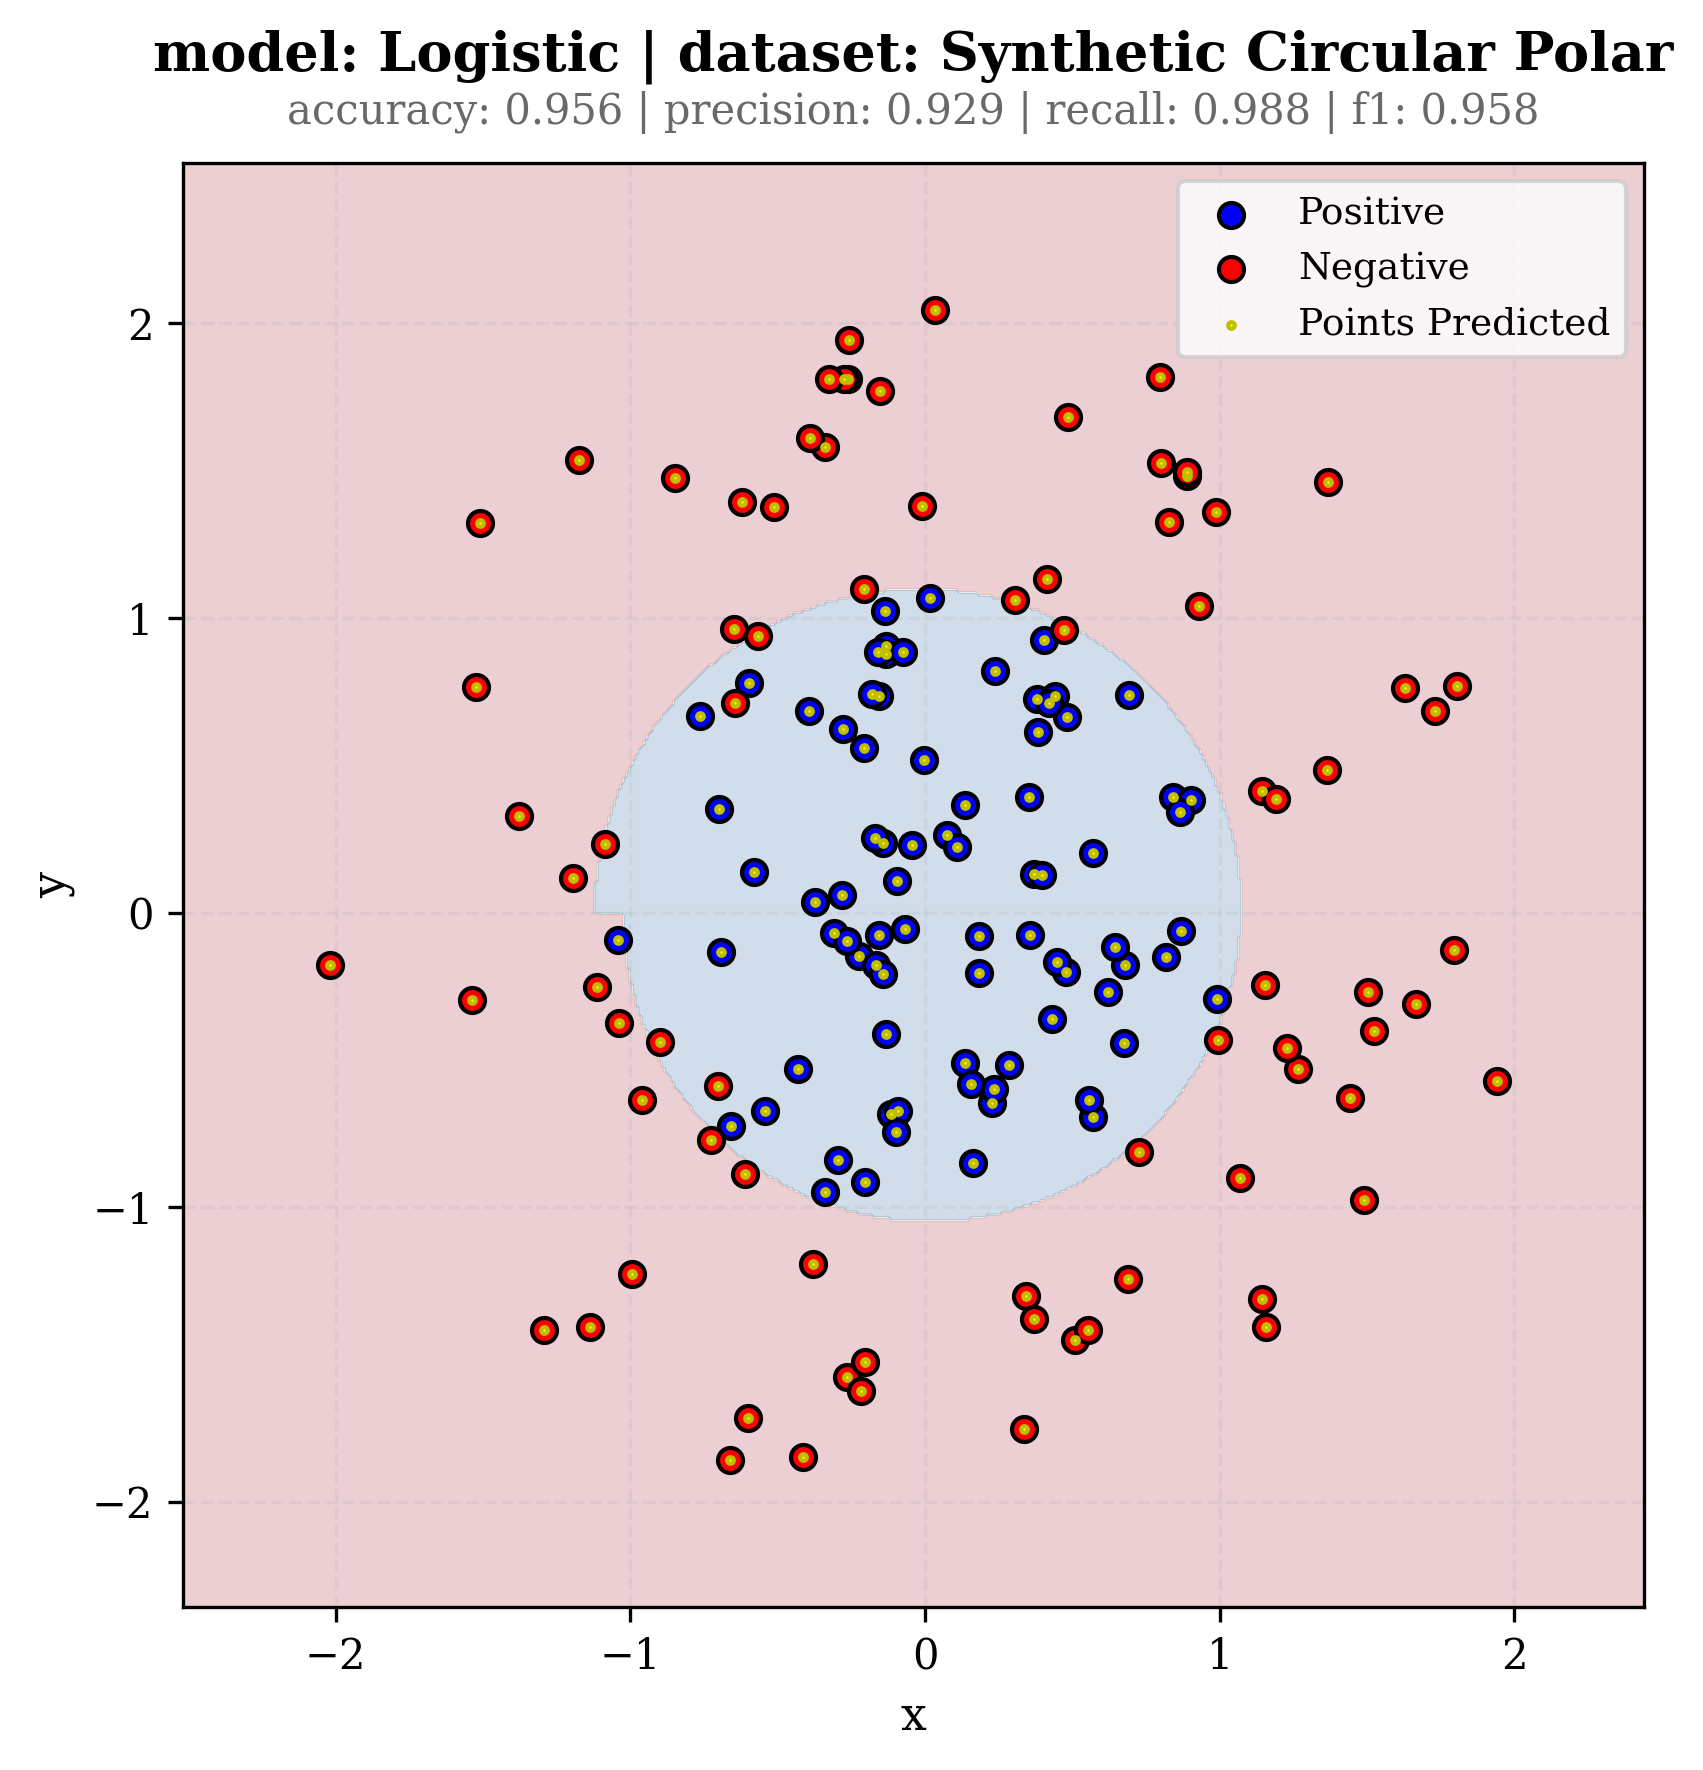

In [11]:
lr_ax.set_aspect('equal')
display(lr_fig)

In [12]:
plot_manager.handle(lr_fig, name='logi_regr_synthetic_circular_polar_dataset')

### Logistic on Radius Only

In [13]:
lr_modelR = LogisticRegression(random_state=random_state)
lr_modelR.fit(synth_polar_dataset.X[['r']], synth_polar_dataset.y)
lr_metricsR = ModelMetrics('Logistic Regression', 'R-only', synth_polar_dataset.y, lr_modelR.predict(synth_polar_dataset.X[['r']]))
lr_metricsR.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metricsR.to_pandas().rename(index={0:'Logistic Regression | R-only'})])

wrapped_modelR = Model1DWrapper(trained_model=lr_modelR, vars_list=['r'])

lr_R_fig, lr_R_ax = plot_decision_boundary(
    model=wrapped_modelR, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Circular R-only',
    metrics=lr_metricsR.to_dict()
)

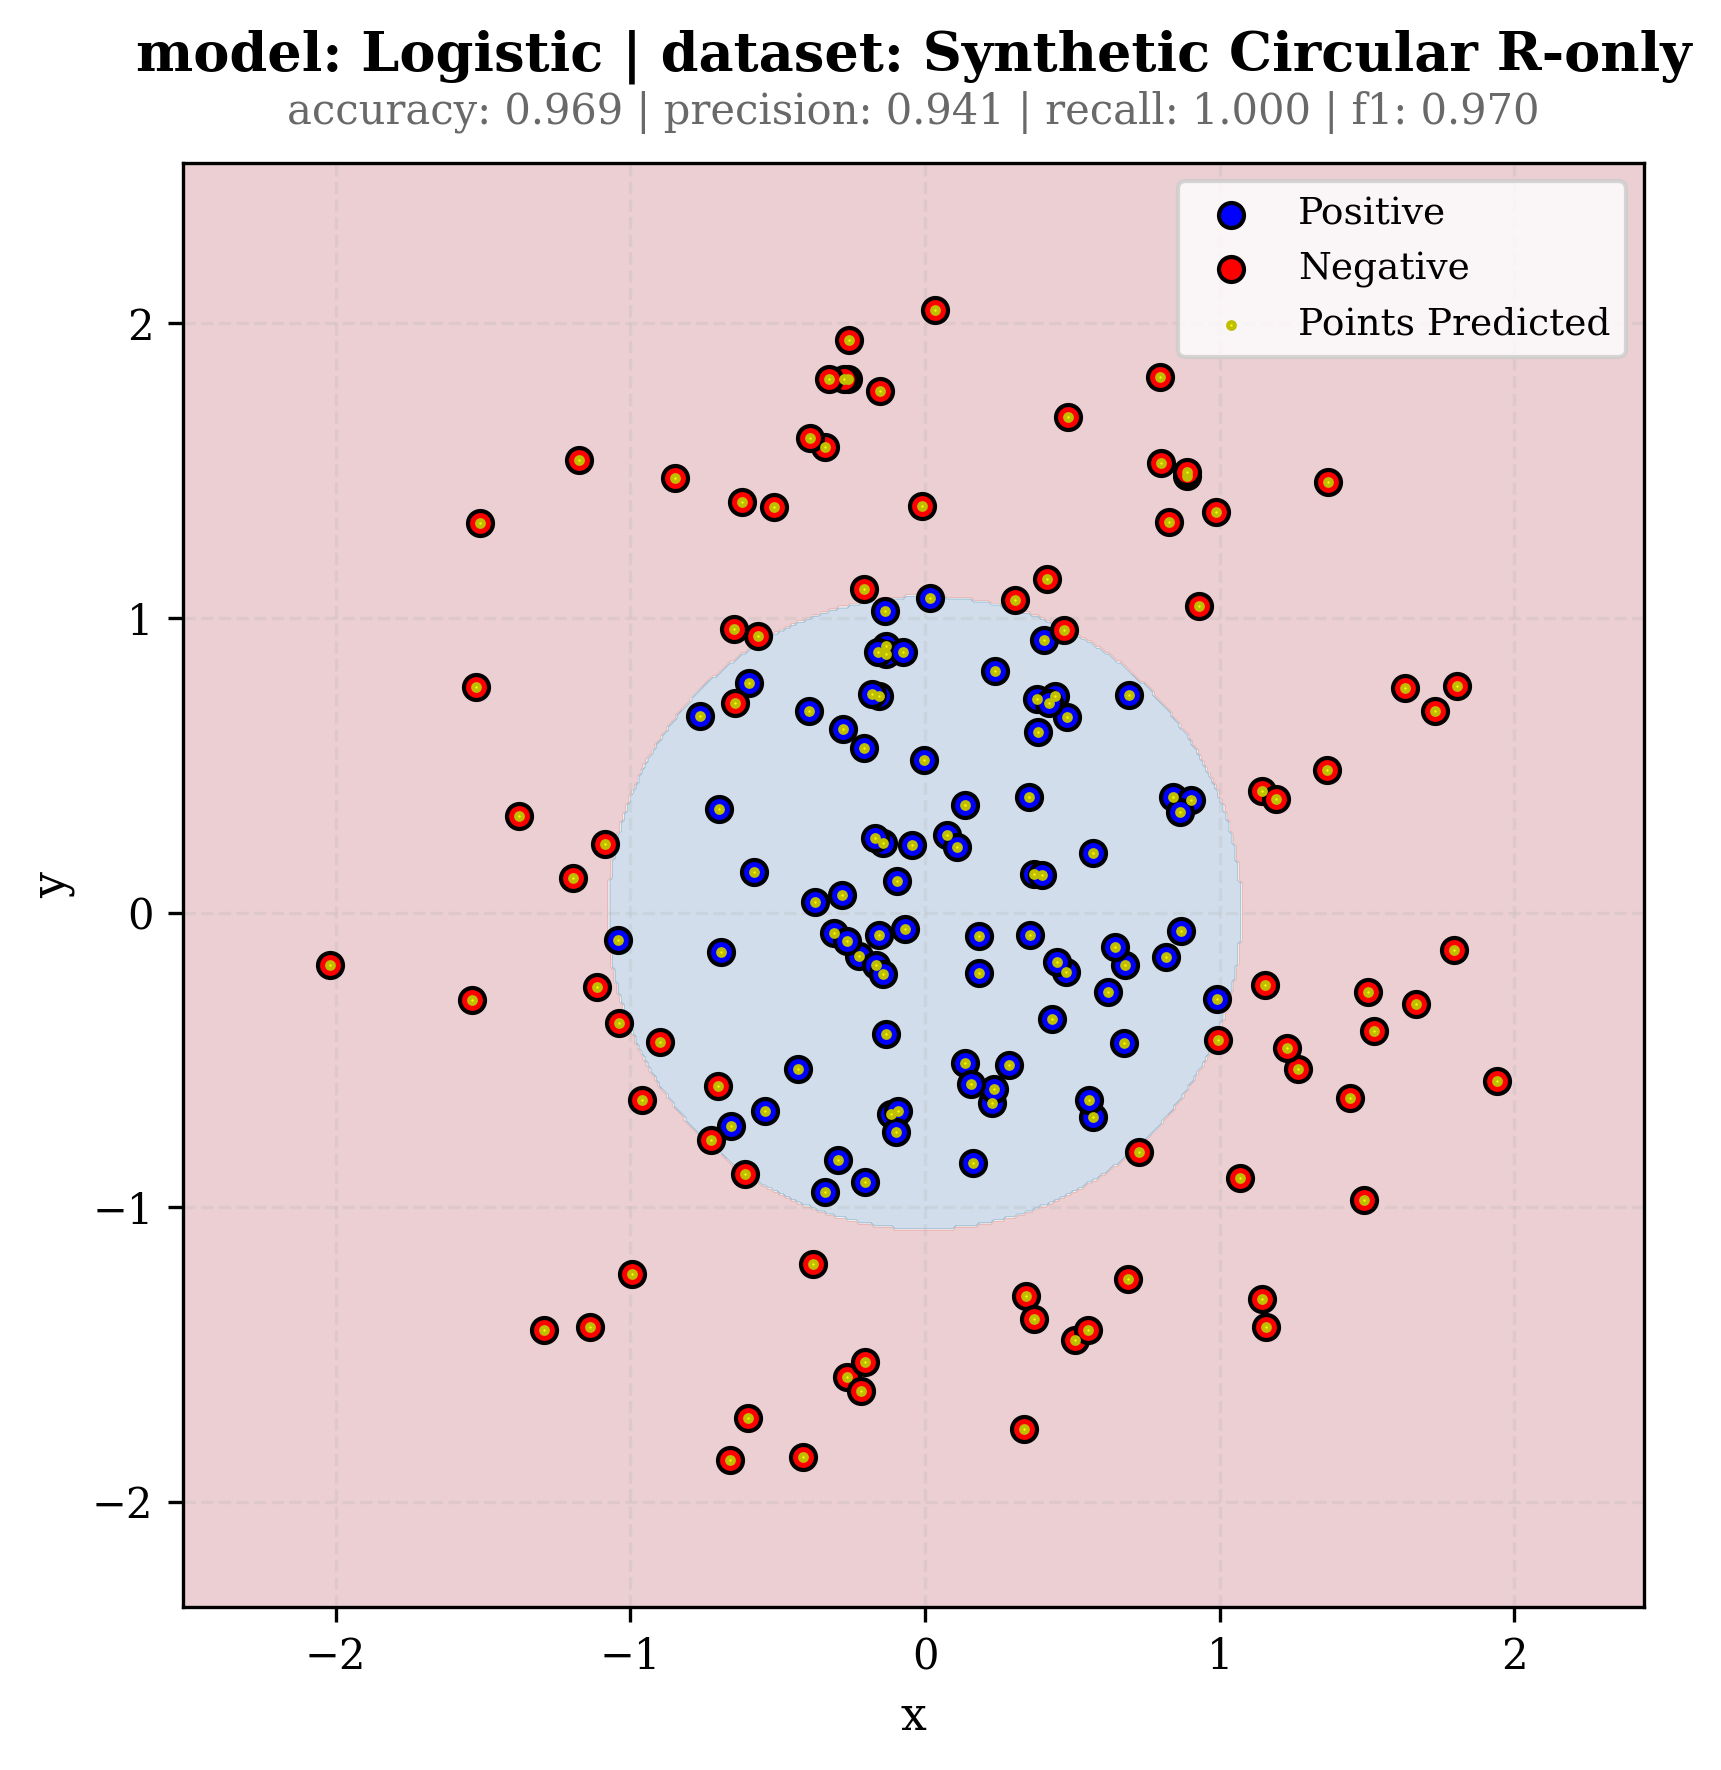

In [14]:
lr_R_ax.set_aspect('equal')
display(lr_R_fig)

In [15]:
plot_manager.handle(lr_R_fig, name='logi_regr_synthetic_circular_r_dataset')

### Logistic Regression on Featured Coordinates

In [16]:
lr_model_r2cos2 = LogisticRegression(random_state=random_state)
lr_model_r2cos2.fit(synth_r2cos2_dataset.X, synth_r2cos2_dataset.y)
lr_metrics_r2cos2 = ModelMetrics('Logistic Regression', 'r^2,cos2()', synth_r2cos2_dataset.y, lr_model_r2cos2.predict(synth_r2cos2_dataset.X))
lr_metrics_r2cos2.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metrics_r2cos2.to_pandas().rename(index={0:'Logistic Regression | Curvilinear'})])

dataset_label = r'$\cos^2{\theta}$'

lr_r2cos2_fig, lr_r2cos2_ax = plot_decision_boundary(
    model=lr_model_r2cos2, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_r2cos2_sqd, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Circular Curvilinear',
    metrics=lr_metrics_r2cos2.to_dict()
)

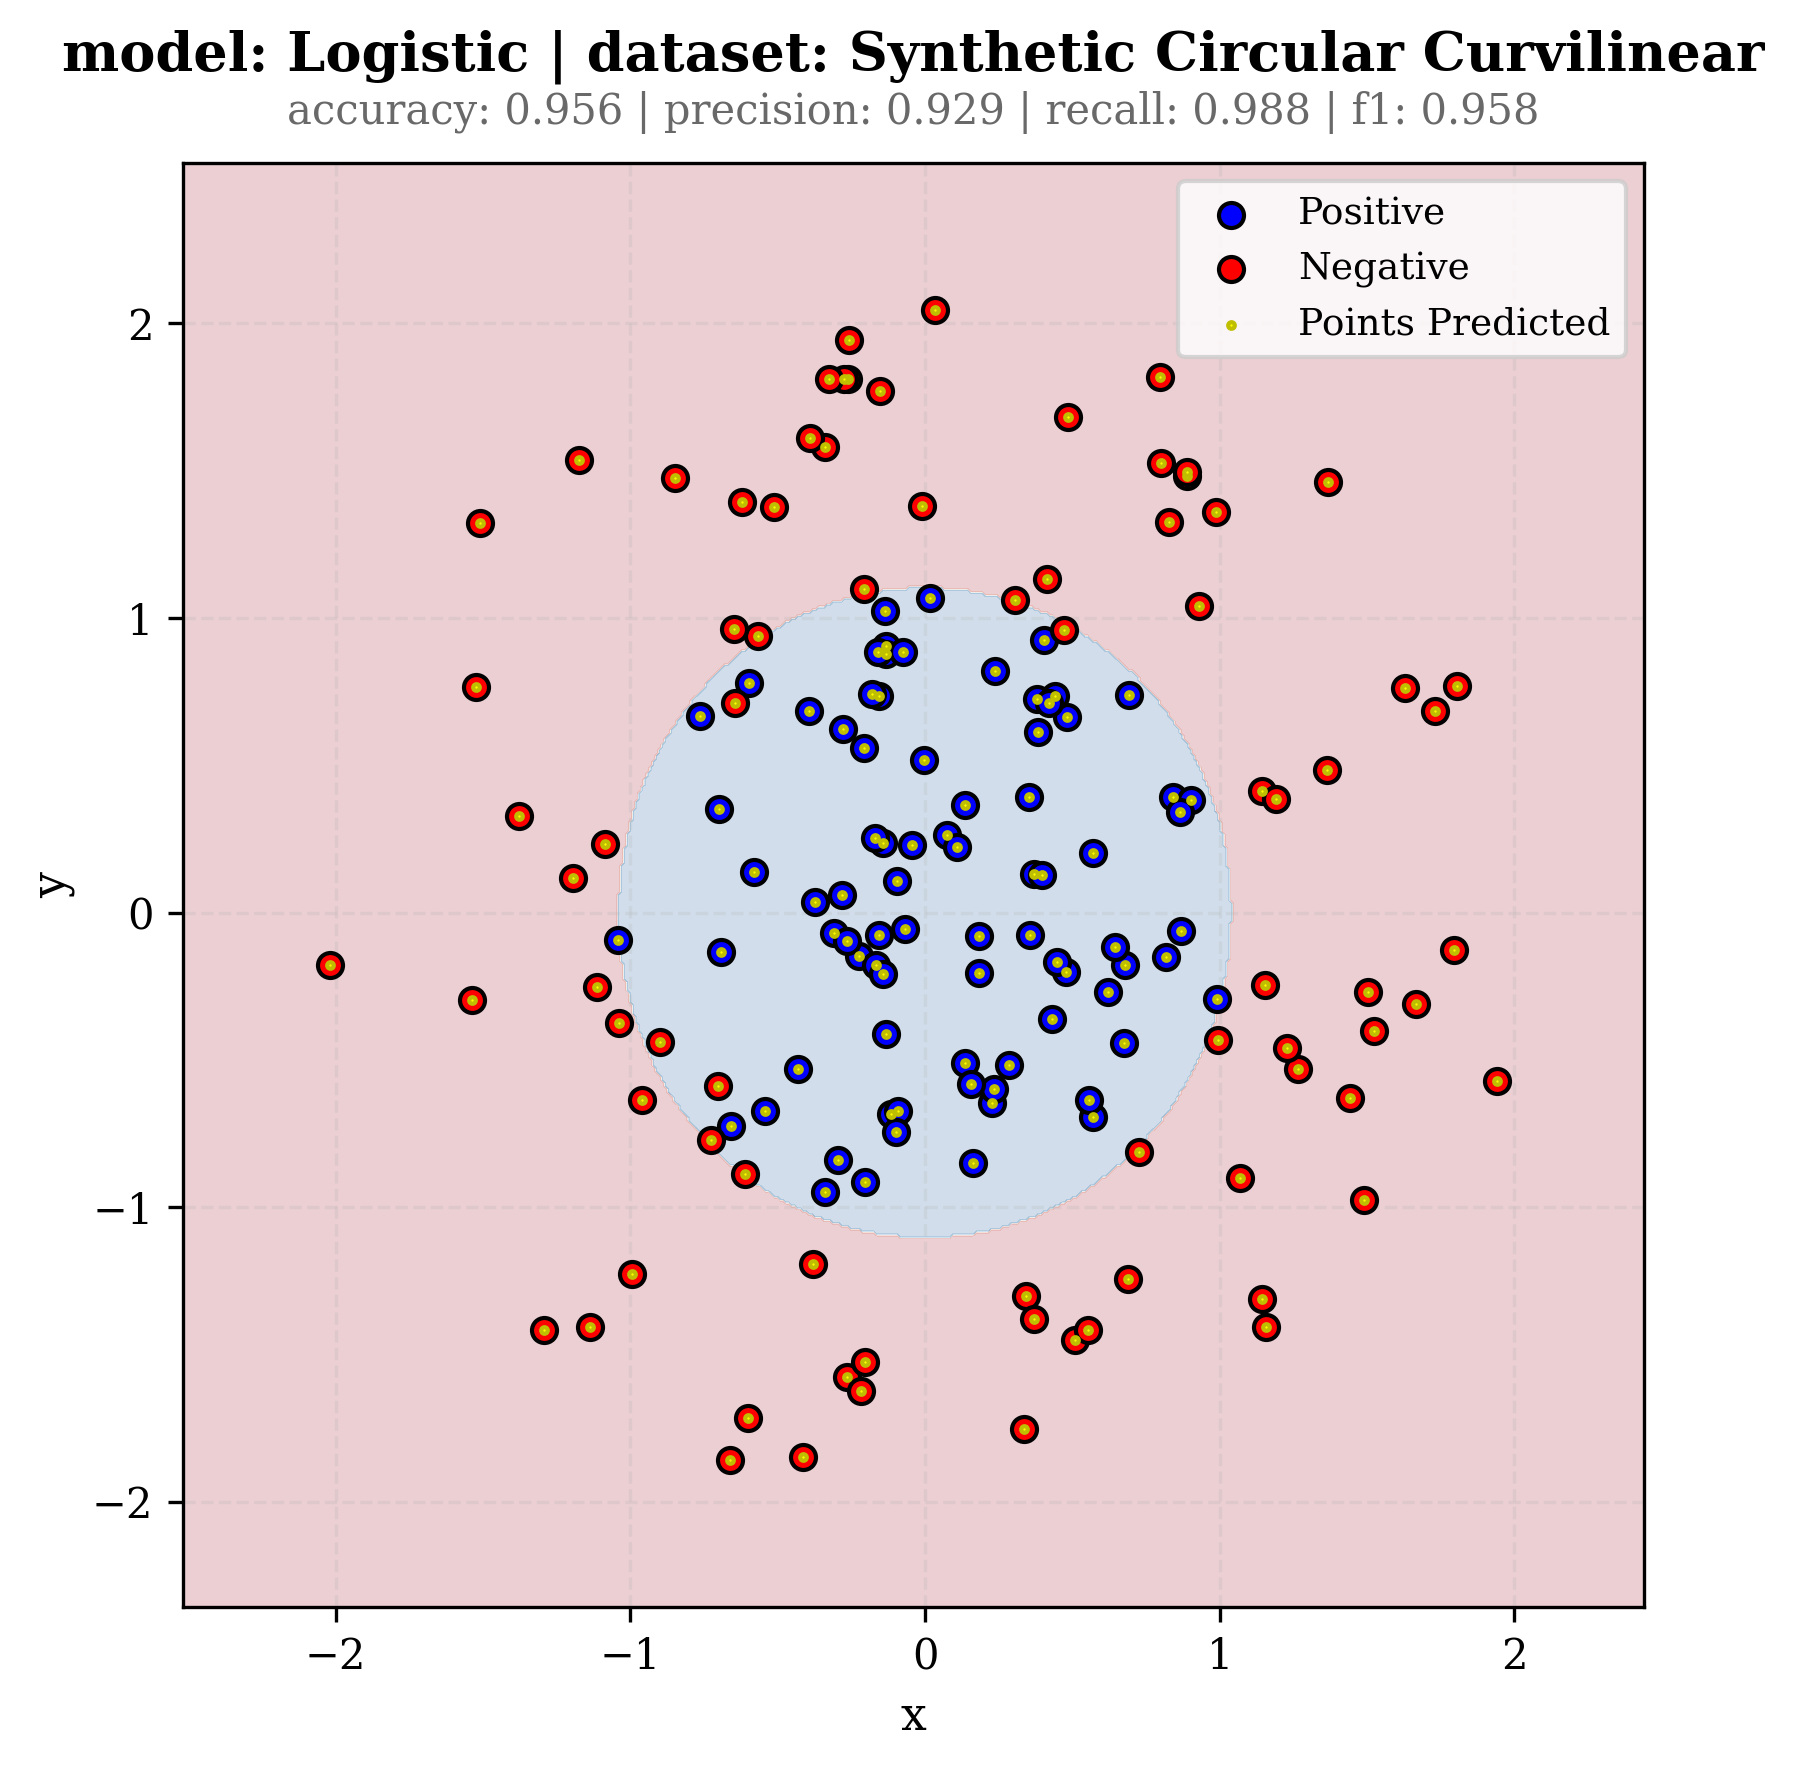

In [17]:
lr_r2cos2_ax.set_aspect('equal')
display(lr_r2cos2_fig)

In [18]:
plot_manager.handle(lr_r2cos2_fig, name='logi_regr_synthetic_circular_curvilinear_dataset')

### SVM

In [19]:
svm_model = SVC(kernel='rbf', random_state=random_state)
svm_model.fit(synth_cartesian_dataset.X, synth_cartesian_dataset.y)
svm_metrics = ModelMetrics('SVM', 'Cartesian', synth_cartesian_dataset.y, svm_model.predict(synth_cartesian_dataset.X))
svm_metrics.compute_metrics()
metrics_df = pd.concat([metrics_df, svm_metrics.to_pandas().rename(index={0:'SVM | Cartesian'})])

svm_fig, svm_ax = plot_decision_boundary(
    model=svm_model, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Synthetic Cartesian',
    metrics=svm_metrics.to_dict()
)

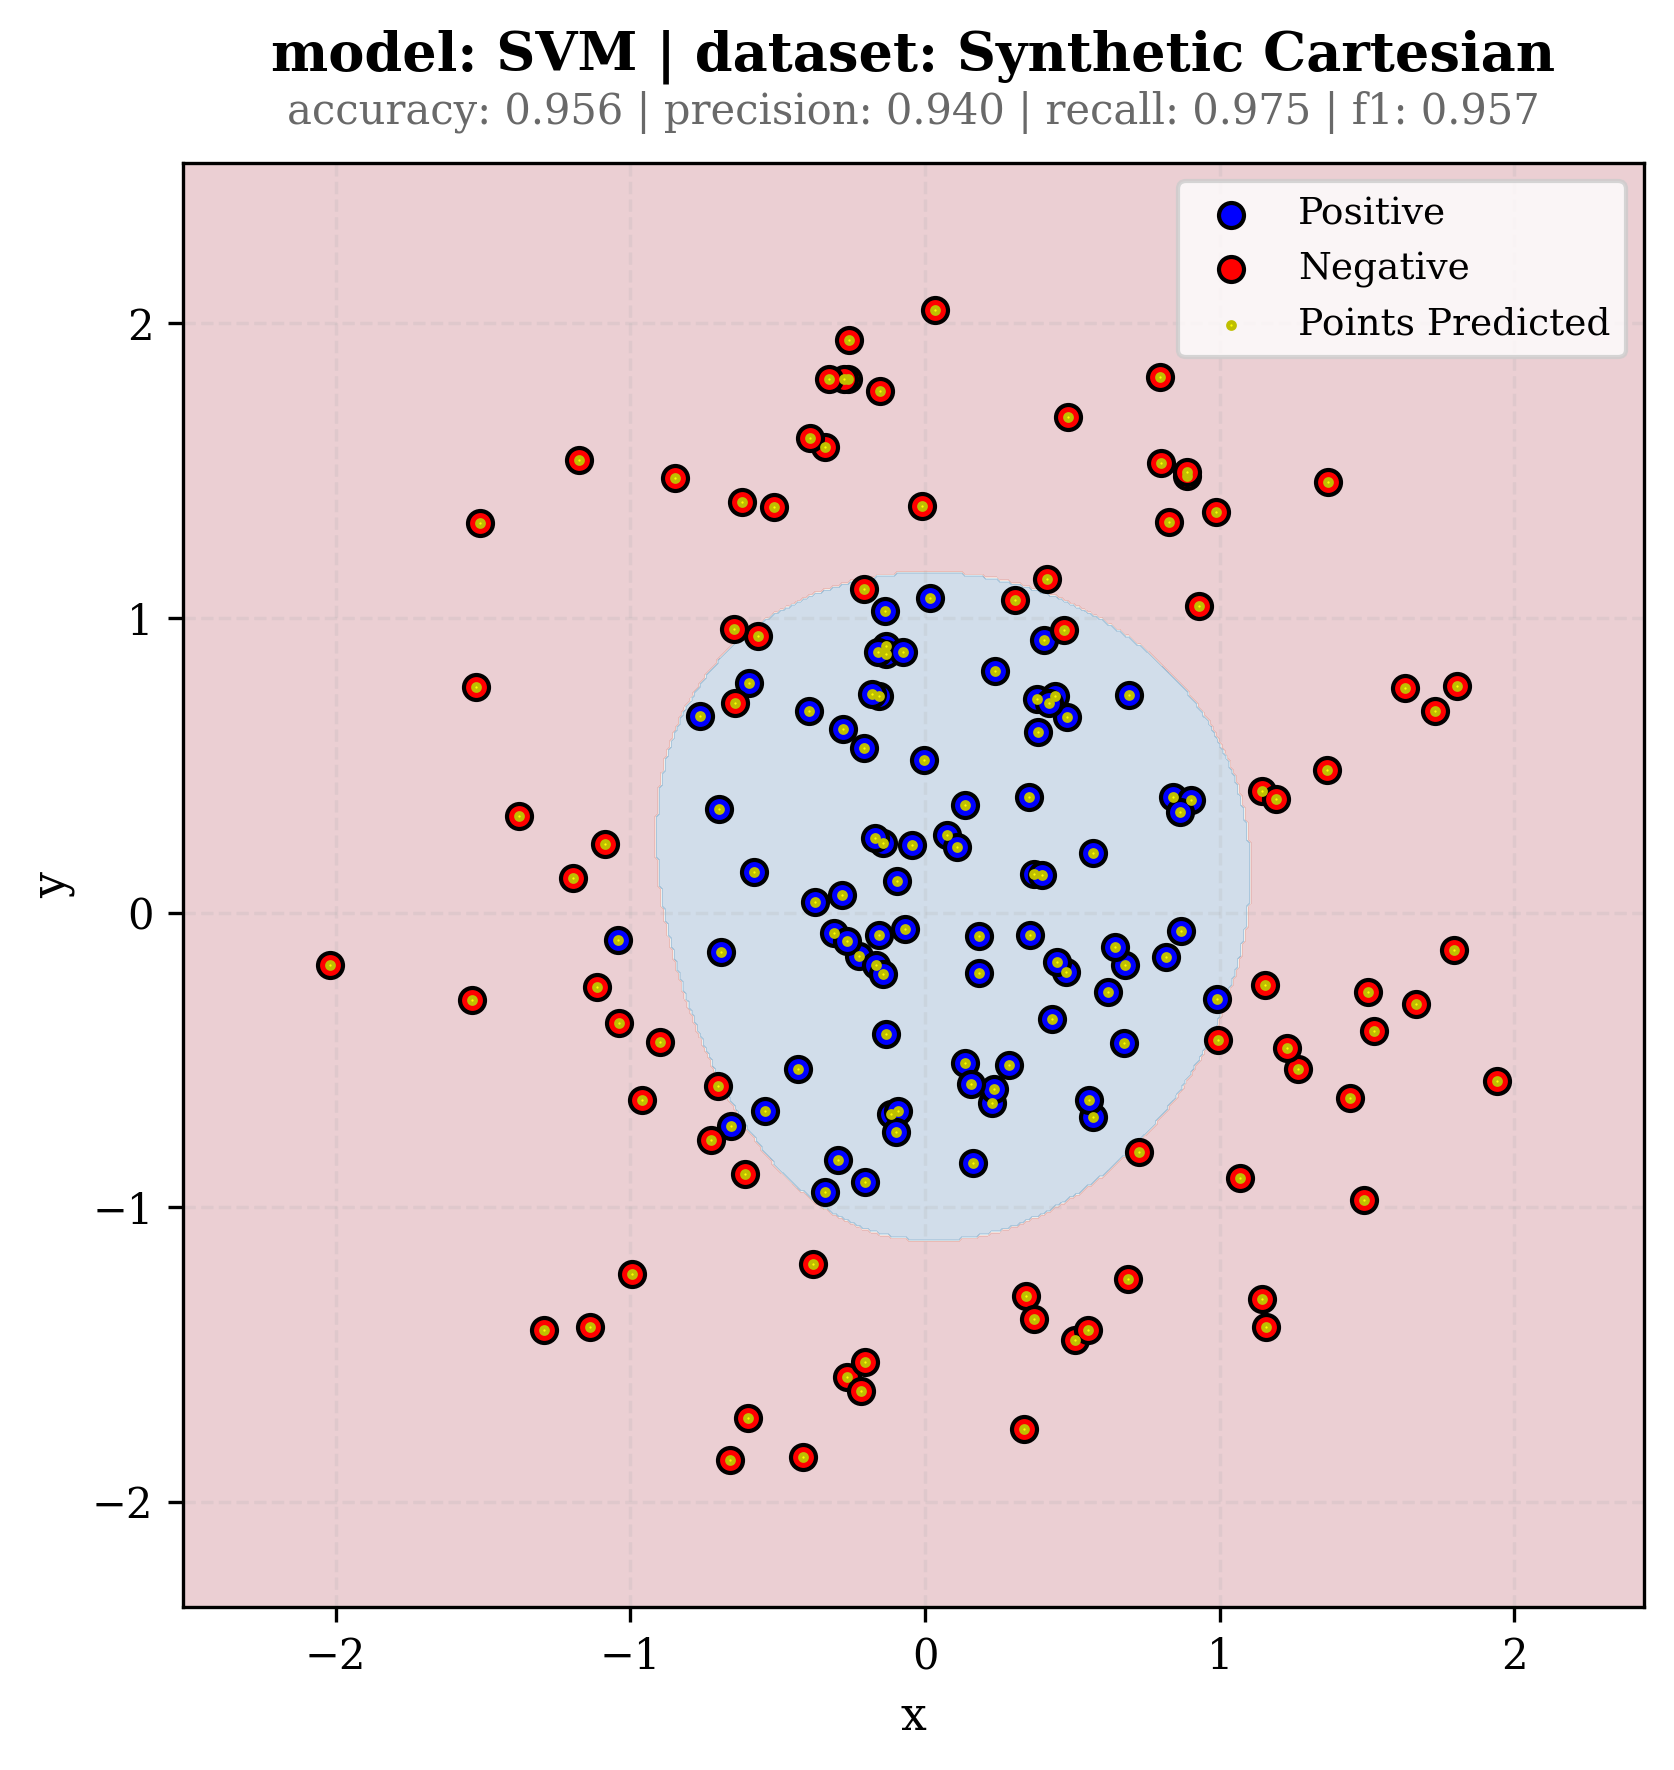

In [20]:
svm_ax.set_aspect('equal')
display(svm_fig)

In [21]:
plot_manager.handle(svm_fig, name='svm_synthetic_circular_cartesian_dataset')

### Sample Summary

In [22]:
display(metrics_df.loc[~metrics_df.index.duplicated(keep='first')])

,accuracy,precision,recall,f1
Generator decision boundary,0.93750,0.972973,0.9000,0.935065
Logistic Regression | Polar,0.95625,0.929412,0.9875,0.957576
Logistic Regression | R-only,0.96875,0.941176,1.0000,0.969697
Logistic Regression | Curvilinear,0.95625,0.929412,0.9875,0.957576
SVM | Cartesian,0.95625,0.939759,0.9750,0.957055


# Radially Symmetric Data with Noise Model Evaluation

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

### Small Datasets

In [24]:
r_cutoff = 1.0
r_max = 2 * r_cutoff
theta_kappa = 1000
r_noise = 0.1
num_class_points = 100

In [25]:
synth_polar_pos_dataset = generate_custom_polar_dataset(
    label=1,
    num_points=num_class_points,
    theta_noise=theta_kappa,
    r_noise=r_noise,
    r_outer_bound_func=lambda theta: np.array([r_cutoff]*theta.size),
    random_seed=random_state
)

synth_polar_neg_dataset = generate_custom_polar_dataset(
    label=0,
    num_points=num_class_points,
    r_inner_bound_func=lambda theta: np.array([r_cutoff]*theta.size),
    r_outer_bound_func=lambda theta: np.array([r_max]*theta.size),
    theta_noise=theta_kappa,
    r_noise=r_noise,
    random_seed=random_state
)

synth_polar_dataset = PointsDataset.merge_dataset(synth_polar_pos_dataset, synth_polar_neg_dataset)
synth_cartesian_dataset = synth_polar_dataset.transform(polar_to_cartesian)
synth_r2cos2_dataset = synth_polar_dataset.transform(polar_to_curvilinear_r2cos2theta)

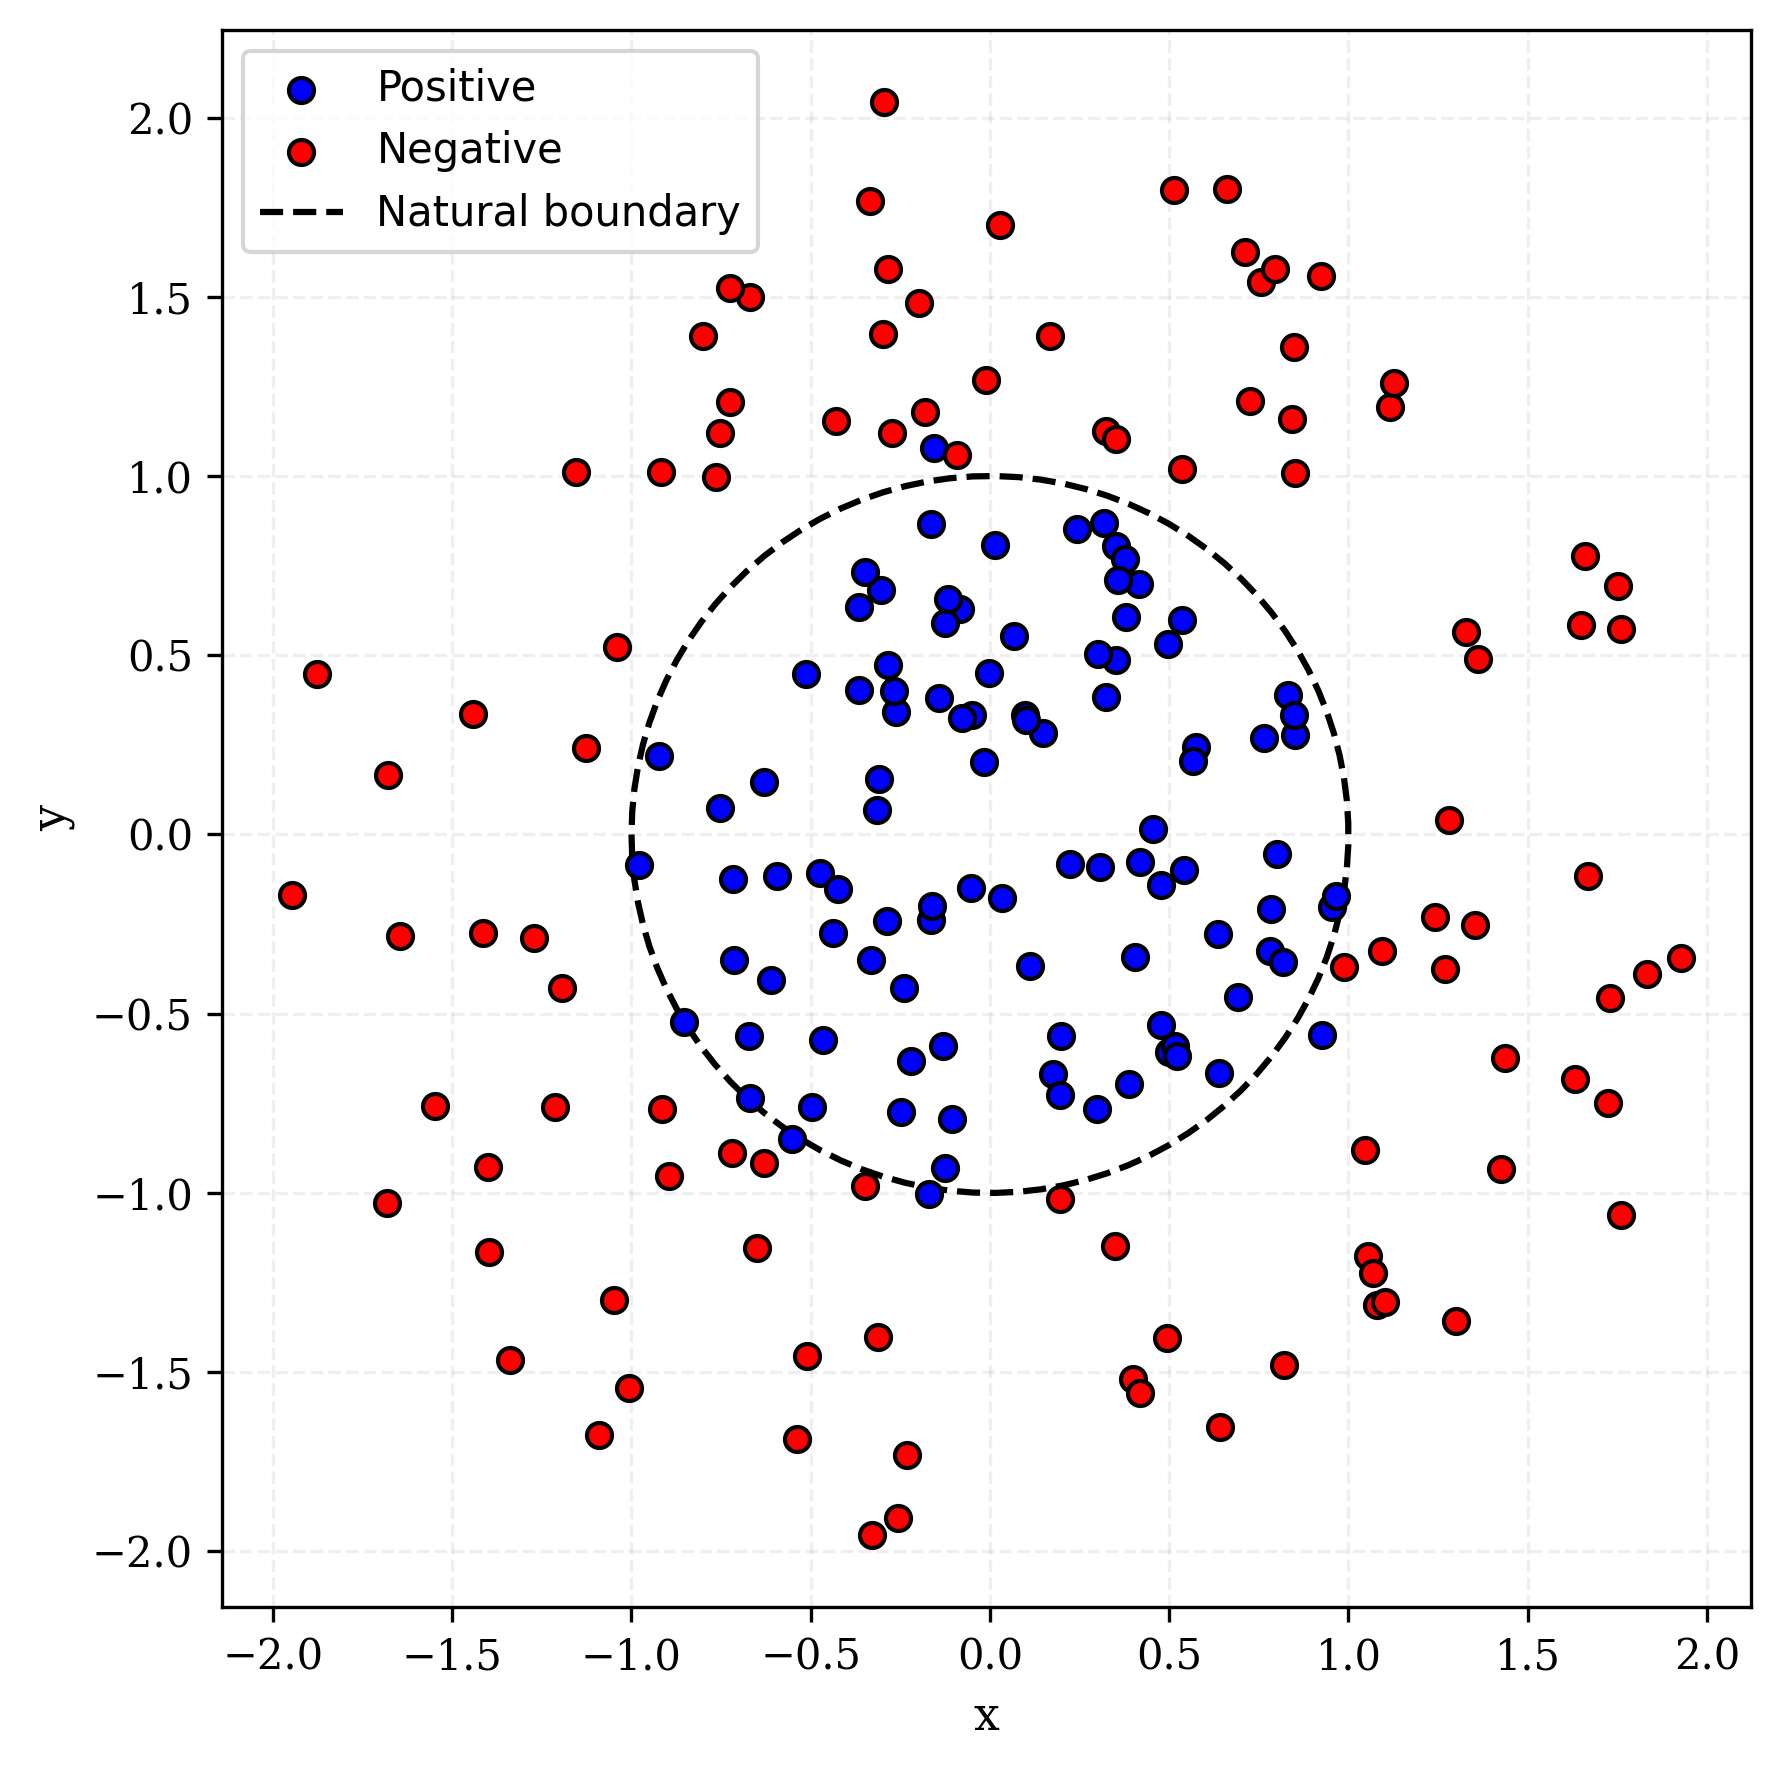

In [26]:
sample_fig, sample_ax = plot_in_rectangular_coordinates(
    synth_cartesian_dataset.X, 
    synth_cartesian_dataset.y,
    title=""
)

Thetas = np.linspace(-np.pi, np.pi, 100)
sample_ax.plot(r_cutoff*np.cos(Thetas), r_cutoff*np.sin(Thetas), color='black', linestyle='--', label='Natural boundary')
sample_ax.legend()
sample_ax.set_aspect('equal')

display(sample_fig)

In [27]:
plot_manager.handle(sample_fig, name='synthetic_circular_small_dataset')

In [28]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(x1=synth_cartesian_dataset.X['x'], x2=synth_cartesian_dataset.X['y'], resolution=500)
grid_cartesian = grid_cartesian.rename(columns={'x1': 'x', 'x2': 'y'})

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_cartesian)

# Transform polar into curvilinear grid
grid_r2cos2_sqd = pd.DataFrame({'r^2': grid_polar['r']**2, 'cos^2()': np.cos(grid_polar['theta'])**2})

#### Cross Validation

In [29]:
# Initialize with 10 folds
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=random_state
)

folds = list(skf.split(synth_cartesian_dataset.X, synth_cartesian_dataset.y))

In [30]:
logreg_polar_pipeline = Pipeline([
    ("logreg_polar", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_polar_results = cross_validate(
    logreg_polar_pipeline,
    synth_polar_dataset.X,
    synth_polar_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_R_pipeline = Pipeline([
    ("logreg_R", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_R_results = cross_validate(
    logreg_R_pipeline,
    synth_polar_dataset.X[['r']],
    synth_polar_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_r2cos2_pipeline = Pipeline([
    ("logreg_cos2", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_r2cos2_results = cross_validate(
    logreg_r2cos2_pipeline,
    synth_r2cos2_dataset.X,
    synth_r2cos2_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_results = cross_validate(
    svm_pipeline,
    synth_cartesian_dataset.X,
    synth_cartesian_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [31]:
models_test = {}
models_train = {}

for key in svm_results.keys():
    svm_metrics = svm_results[key]
    logreg_metrics = logreg_polar_results[key]
    logreg_R_metrics = logreg_R_results[key]
    logreg_cos2_metrics = logreg_r2cos2_results[key]

    if 'train' in key:
        models_train[key] = {}
        my_dict = models_train
    else:
        models_test[key] = {}
        my_dict = models_test

    my_dict[key] = [f'{np.mean(svm_metrics):.5f} +/- {np.std(svm_metrics):.5f}',
                    f'{np.mean(logreg_metrics):.5f} +/- {np.std(logreg_metrics):.5f}', 
                    f'{np.mean(logreg_R_metrics):.5f} +/- {np.std(logreg_R_metrics):.5f}', 
                    f'{np.mean(logreg_cos2_metrics):.5f} +/- {np.std(logreg_cos2_metrics):.5f}']

model_names = ['SVM', 'LogReg-Polar', 'LogReg-R-only', 'LogReg-r2cos2']

models_test_df = pd.DataFrame(models_test, index=model_names)
models_train_df = pd.DataFrame(models_train, index=model_names)

display(models_test_df)
display(models_train_df)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
SVM,0.00060 +/- 0.00005,0.00184 +/- 0.00005,0.97500 +/- 0.03354,0.97273 +/- 0.04166,0.98000 +/- 0.06000,0.97460 +/- 0.03563
LogReg-Polar,0.00134 +/- 0.00070,0.00266 +/- 0.00071,0.97500 +/- 0.02500,0.96364 +/- 0.04454,0.99000 +/- 0.03000,0.97569 +/- 0.02435
LogReg-R-only,0.00072 +/- 0.00004,0.00184 +/- 0.00008,0.97500 +/- 0.02500,0.96364 +/- 0.04454,0.99000 +/- 0.03000,0.97569 +/- 0.02435
LogReg-r2cos2,0.00078 +/- 0.00004,0.00180 +/- 0.00004,0.97500 +/- 0.02500,0.96364 +/- 0.04454,0.99000 +/- 0.03000,0.97569 +/- 0.02435


,train_accuracy,train_precision,train_recall,train_f1
SVM,0.97833 +/- 0.00389,0.97159 +/- 0.00708,0.98556 +/- 0.00711,0.97849 +/- 0.00386
LogReg-Polar,0.97333 +/- 0.00333,0.95810 +/- 0.00555,0.99000 +/- 0.00333,0.97378 +/- 0.00323
LogReg-R-only,0.97722 +/- 0.00524,0.96135 +/- 0.00516,0.99444 +/- 0.00745,0.97760 +/- 0.00519
LogReg-r2cos2,0.97611 +/- 0.00434,0.96127 +/- 0.00515,0.99222 +/- 0.00509,0.97649 +/- 0.00426


### Medium Datasets

In [32]:
num_class_points = 500
r_cutoff = 1.0
r_max = 2 * r_cutoff
theta_kappa = 1000
r_noise = 0.1

In [33]:
synth_polar_pos_dataset = generate_custom_polar_dataset(
    label=1,
    num_points=num_class_points,
    theta_noise=theta_kappa,
    r_noise=r_noise,
    r_outer_bound_func=lambda theta: np.array([r_cutoff]*theta.size)
)

synth_polar_neg_dataset = generate_custom_polar_dataset(
    label=0,
    num_points=num_class_points,
    r_inner_bound_func=lambda theta: np.array([r_cutoff]*theta.size),
    r_outer_bound_func=lambda theta: np.array([r_max]*theta.size),
    theta_noise=theta_kappa,
    r_noise=r_noise
)

synth_polar_dataset = PointsDataset.merge_dataset(synth_polar_pos_dataset, synth_polar_neg_dataset)
synth_cartesian_dataset = synth_polar_dataset.transform(polar_to_cartesian)
synth_r2cos2_dataset = synth_polar_dataset.transform(polar_to_curvilinear_r2cos2theta)

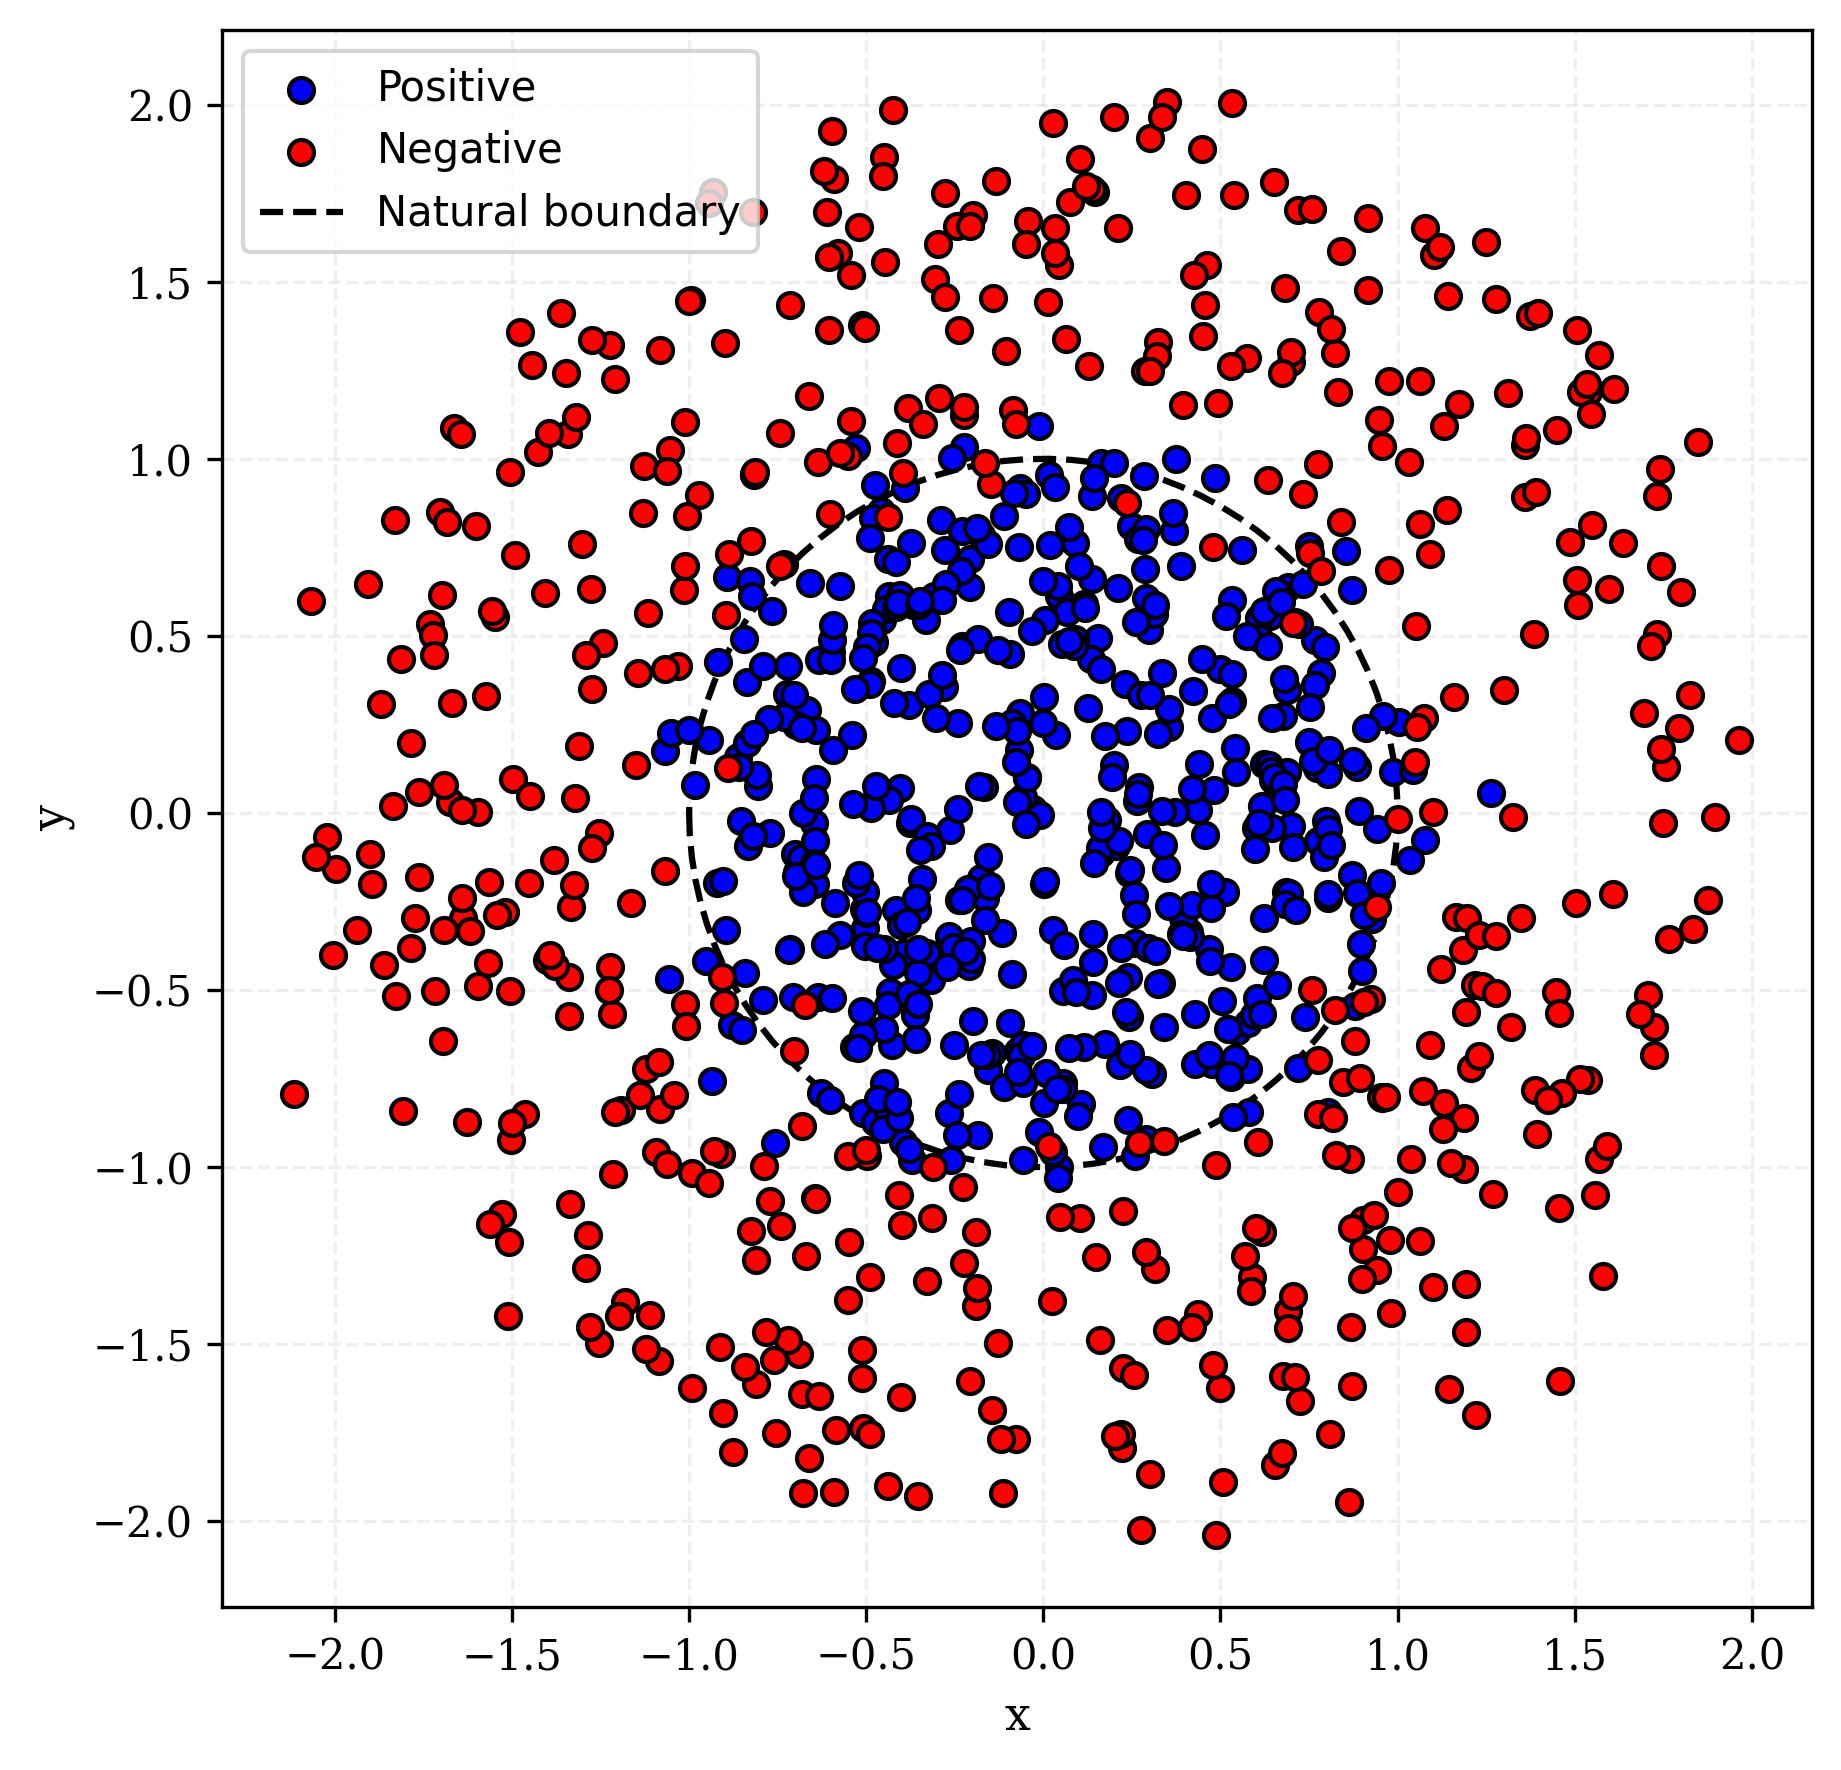

In [34]:
sample_fig, sample_ax = plot_in_rectangular_coordinates(
    synth_cartesian_dataset.X, 
    synth_cartesian_dataset.y,
    title=""
)

Thetas = np.linspace(-np.pi, np.pi, 100)
sample_ax.plot(r_cutoff*np.cos(Thetas), r_cutoff*np.sin(Thetas), color='black', linestyle='--', label='Natural boundary')
sample_ax.legend()
sample_ax.set_aspect('equal')

display(sample_fig)

In [35]:
plot_manager.handle(sample_fig, name='synthetic_circular_medium_dataset')

In [36]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(x1=synth_cartesian_dataset.X['x'], x2=synth_cartesian_dataset.X['y'], resolution=500)
grid_cartesian = grid_cartesian.rename(columns={'x1': 'x', 'x2': 'y'})

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_cartesian)

# Transform polar into curvilinear grid
grid_r2cos2_sqd = pd.DataFrame({'r^2': grid_polar['r']**2, 'cos^2()': np.cos(grid_polar['theta'])**2})

#### Cross Validation

In [37]:
# Initialize with 10 folds
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=random_state
)

folds = list(skf.split(synth_cartesian_dataset.X, synth_cartesian_dataset.y))

In [38]:
logreg_polar_pipeline = Pipeline([
    ("logreg_polar", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_polar_results = cross_validate(
    logreg_polar_pipeline,
    synth_polar_dataset.X,
    synth_polar_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_R_pipeline = Pipeline([
    ("logreg_R", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_R_results = cross_validate(
    logreg_R_pipeline,
    synth_polar_dataset.X[['r']],
    synth_polar_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_cos2_pipeline = Pipeline([
    ("logreg_cos2", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg__cos2_results = cross_validate(
    logreg_cos2_pipeline,
    synth_r2cos2_dataset.X,
    synth_r2cos2_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_results = cross_validate(
    svm_pipeline,
    synth_cartesian_dataset.X,
    synth_cartesian_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [39]:
models_test = {}
models_train = {}

for key in svm_results.keys():
    svm_metrics = svm_results[key]
    logreg_metrics = logreg_polar_results[key]
    logreg_R_metrics = logreg_R_results[key]
    logreg_cos2_metrics = logreg__cos2_results[key]

    if 'train' in key:
        models_train[key] = {}
        my_dict = models_train
    else:
        models_test[key] = {}
        my_dict = models_test

    my_dict[key] = [f'{np.mean(svm_metrics):.5f} +/- {np.std(svm_metrics):.5f}',
                    f'{np.mean(logreg_metrics):.5f} +/- {np.std(logreg_metrics):.5f}', 
                    f'{np.mean(logreg_R_metrics):.5f} +/- {np.std(logreg_R_metrics):.5f}', 
                    f'{np.mean(logreg_cos2_metrics):.5f} +/- {np.std(logreg_cos2_metrics):.5f}']

model_names = ['SVM', 'LogReg-Polar', 'LogReg-R-only', 'LogReg-r2cos2']

models_test_df = pd.DataFrame(models_test, index=model_names)
models_train_df = pd.DataFrame(models_train, index=model_names)

display(models_test_df)
display(models_train_df)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
SVM,0.00190 +/- 0.00005,0.00233 +/- 0.00016,0.95200 +/- 0.01887,0.93846 +/- 0.02465,0.96800 +/- 0.02040,0.95282 +/- 0.01844
LogReg-Polar,0.00189 +/- 0.00155,0.00265 +/- 0.00092,0.96000 +/- 0.01789,0.94297 +/- 0.02727,0.98000 +/- 0.01265,0.96095 +/- 0.01720
LogReg-R-only,0.00097 +/- 0.00008,0.00185 +/- 0.00006,0.95800 +/- 0.01990,0.94108 +/- 0.02907,0.97800 +/- 0.01400,0.95901 +/- 0.01915
LogReg-r2cos2,0.00097 +/- 0.00006,0.00179 +/- 0.00003,0.96000 +/- 0.01732,0.94126 +/- 0.02635,0.98200 +/- 0.01400,0.96101 +/- 0.01667


,train_accuracy,train_precision,train_recall,train_f1
SVM,0.95611 +/- 0.00282,0.93811 +/- 0.00301,0.97667 +/- 0.00425,0.95699 +/- 0.00279
LogReg-Polar,0.95967 +/- 0.00307,0.94285 +/- 0.00383,0.97867 +/- 0.00247,0.96042 +/- 0.00297
LogReg-R-only,0.95867 +/- 0.00252,0.94123 +/- 0.00377,0.97844 +/- 0.00200,0.95947 +/- 0.00242
LogReg-r2cos2,0.95978 +/- 0.00198,0.94060 +/- 0.00318,0.98156 +/- 0.00142,0.96064 +/- 0.00188


### Large Datasets

In [40]:
num_class_points = 2000
r_cutoff = 1.0
r_max = 2 * r_cutoff
theta_kappa = 1000
r_noise = 0.1

In [41]:
synth_polar_pos_dataset = generate_custom_polar_dataset(
    label=1,
    num_points=num_class_points,
    theta_noise=theta_kappa,
    r_noise=r_noise,
    r_outer_bound_func=lambda theta: np.array([r_cutoff]*theta.size)
)

synth_polar_neg_dataset = generate_custom_polar_dataset(
    label=0,
    num_points=num_class_points,
    r_inner_bound_func=lambda theta: np.array([r_cutoff]*theta.size),
    r_outer_bound_func=lambda theta: np.array([r_max]*theta.size),
    theta_noise=theta_kappa,
    r_noise=r_noise
)

synth_polar_dataset = PointsDataset.merge_dataset(synth_polar_pos_dataset, synth_polar_neg_dataset)
synth_cartesian_dataset = synth_polar_dataset.transform(polar_to_cartesian)
synth_r2cos2_dataset = synth_polar_dataset.transform(polar_to_curvilinear_r2cos2theta)

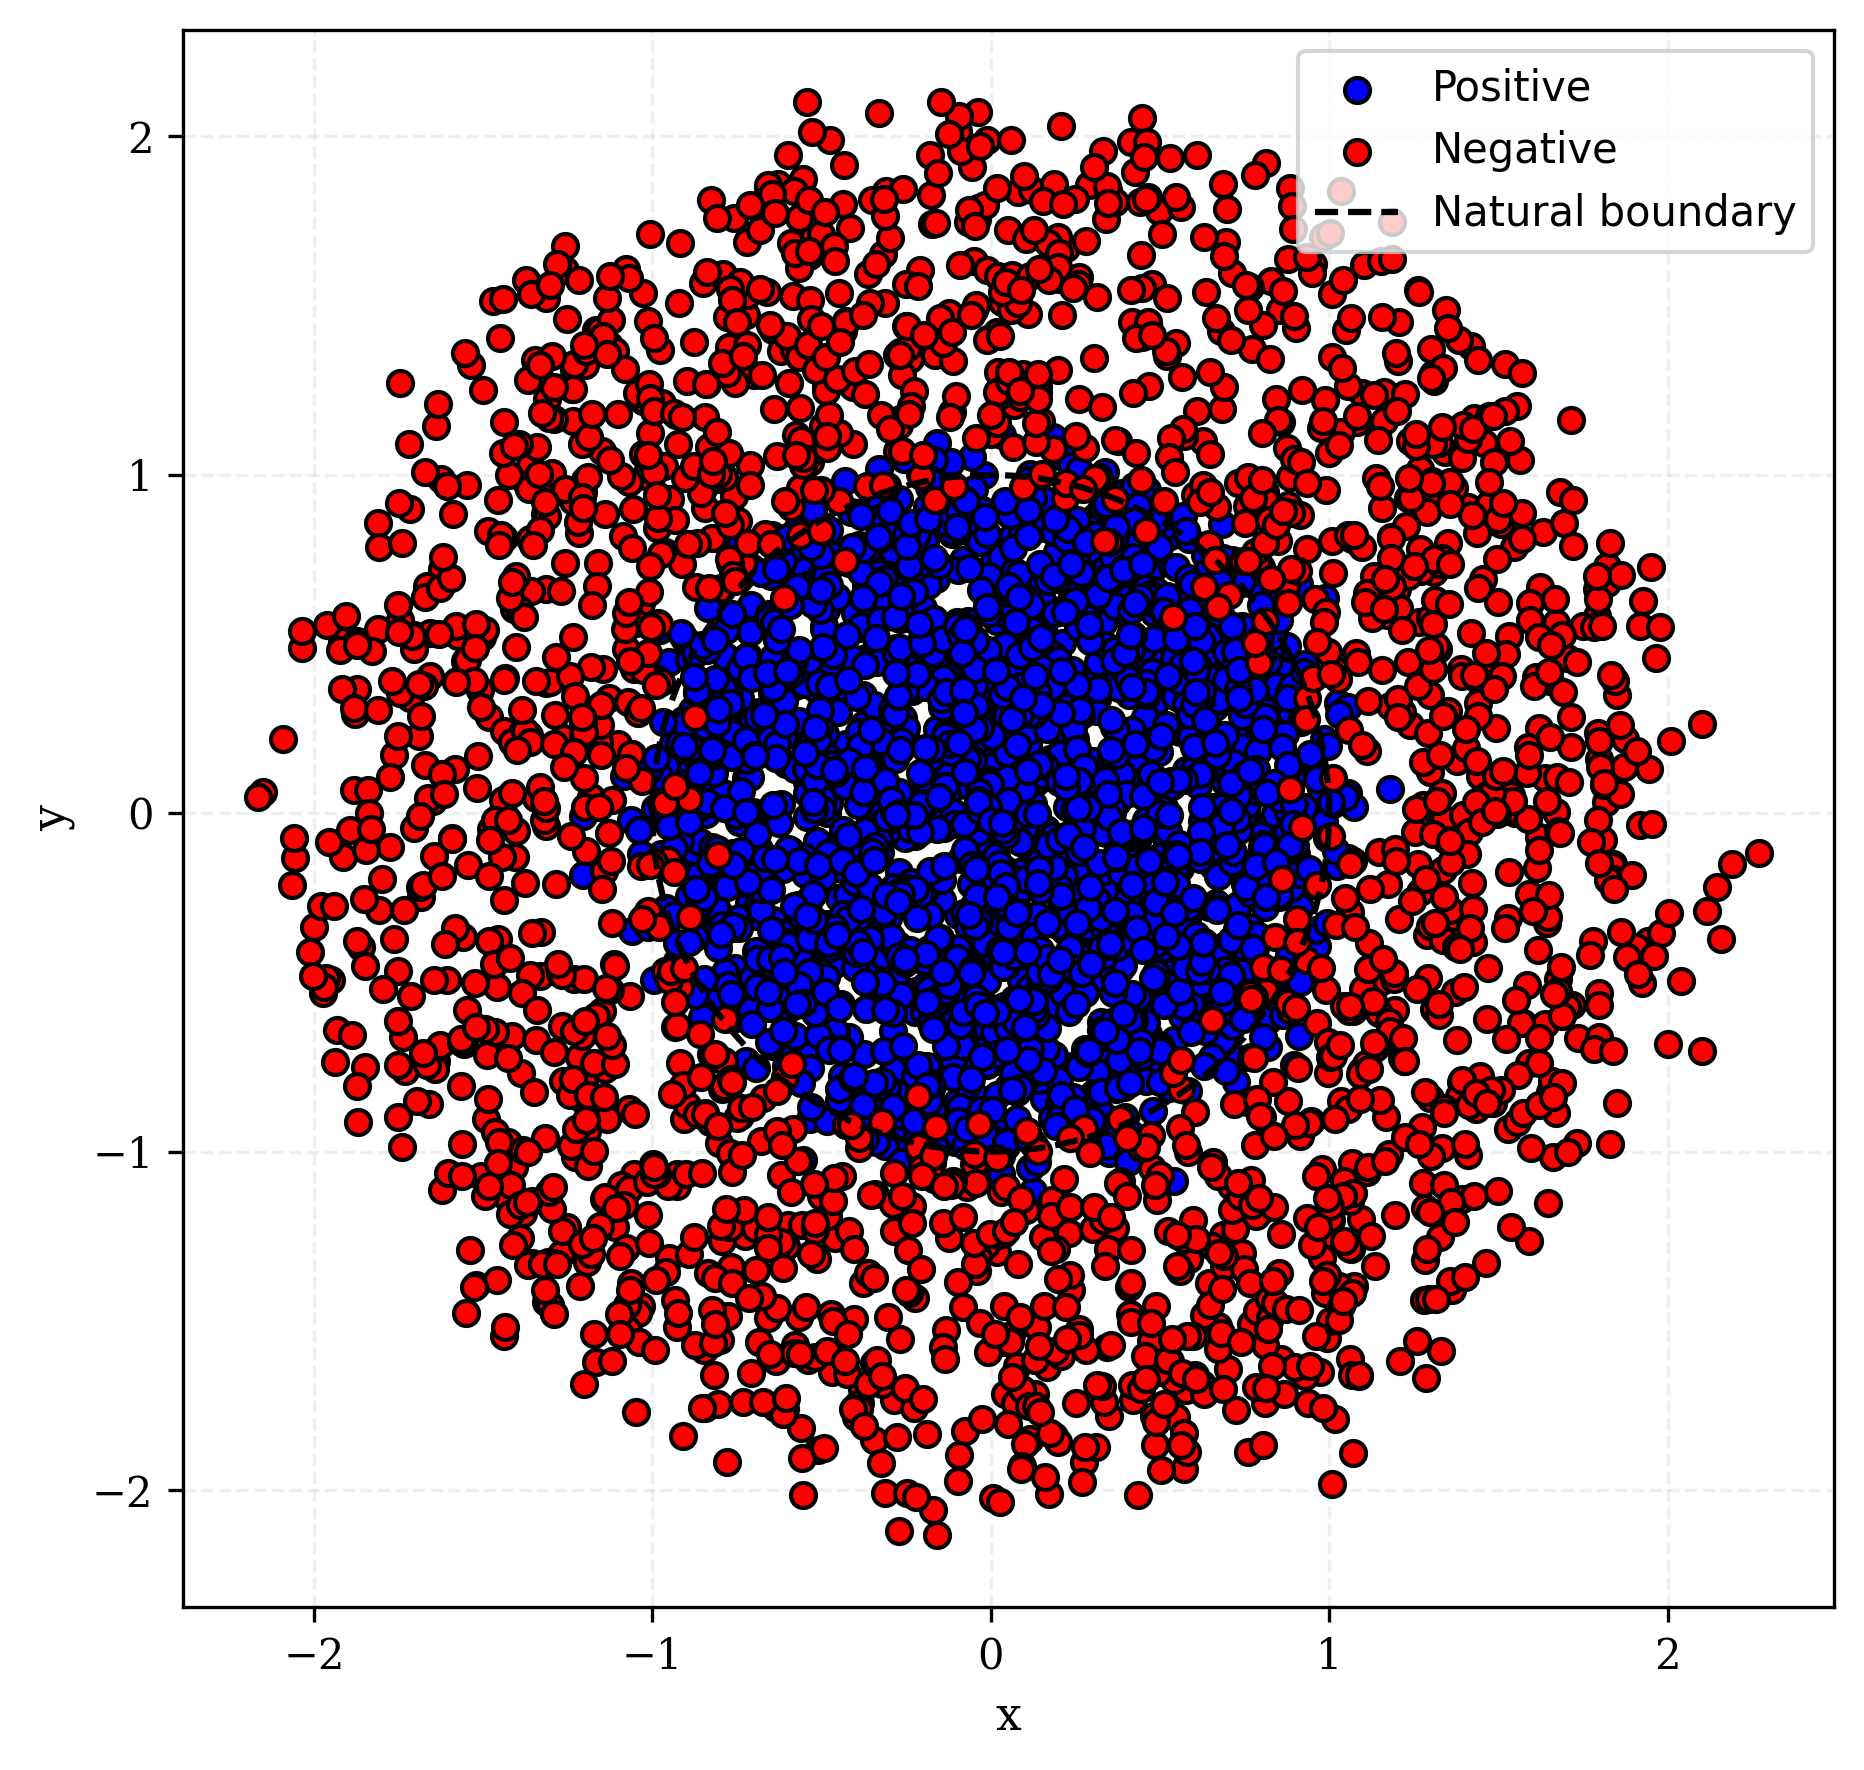

In [42]:
sample_fig, sample_ax = plot_in_rectangular_coordinates(
    synth_cartesian_dataset.X, 
    synth_cartesian_dataset.y,
    title=""
)

Thetas = np.linspace(-np.pi, np.pi, 100)
sample_ax.plot(r_cutoff*np.cos(Thetas), r_cutoff*np.sin(Thetas), color='black', linestyle='--', label='Natural boundary', zorder=5)
sample_ax.legend()
sample_ax.set_aspect('equal')

display(sample_fig)

In [43]:
plot_manager.handle(sample_fig, name='synthetic_circular_large_dataset')

In [44]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(x1=synth_cartesian_dataset.X['x'], x2=synth_cartesian_dataset.X['y'], resolution=500)
grid_cartesian = grid_cartesian.rename(columns={'x1': 'x', 'x2': 'y'})

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_cartesian)

# Transform polar into curvilinear grid
grid_r2cos2_sqd = pd.DataFrame({'r^2': grid_polar['r']**2, 'cos^2()': np.cos(grid_polar['theta'])**2})

#### Cross Validation

In [45]:
# Initialize with 10 folds
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=random_state
)

folds = list(skf.split(synth_cartesian_dataset.X, synth_cartesian_dataset.y))

In [46]:
logreg_polar_pipeline = Pipeline([
    ("logreg_polar", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_polar_results = cross_validate(
    logreg_polar_pipeline,
    synth_polar_dataset.X,
    synth_polar_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_R_pipeline = Pipeline([
    ("logreg_R", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_R_results = cross_validate(
    logreg_R_pipeline,
    synth_polar_dataset.X[['r']],
    synth_polar_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_cos2_pipeline = Pipeline([
    ("logreg_cos2", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg__cos2_results = cross_validate(
    logreg_cos2_pipeline,
    synth_r2cos2_dataset.X,
    synth_r2cos2_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_results = cross_validate(
    svm_pipeline,
    synth_cartesian_dataset.X,
    synth_cartesian_dataset.y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [47]:
models_test = {}
models_train = {}

for key in svm_results.keys():
    svm_metrics = svm_results[key]
    logreg_metrics = logreg_polar_results[key]
    logreg_R_metrics = logreg_R_results[key]
    logreg_cos2_metrics = logreg__cos2_results[key]

    if 'train' in key:
        models_train[key] = {}
        my_dict = models_train
    else:
        models_test[key] = {}
        my_dict = models_test

    my_dict[key] = [f'{np.mean(svm_metrics):.5f} +/- {np.std(svm_metrics):.5f}',
                    f'{np.mean(logreg_metrics):.5f} +/- {np.std(logreg_metrics):.5f}', 
                    f'{np.mean(logreg_R_metrics):.5f} +/- {np.std(logreg_R_metrics):.5f}', 
                    f'{np.mean(logreg_cos2_metrics):.5f} +/- {np.std(logreg_cos2_metrics):.5f}']

model_names = ['SVM', 'LogReg-Polar', 'LogReg-R-only', 'LogReg-r2cos2']

models_test_df = pd.DataFrame(models_test, index=model_names)
models_train_df = pd.DataFrame(models_train, index=model_names)

display(models_test_df)
display(models_train_df)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
SVM,0.01664 +/- 0.00049,0.00666 +/- 0.00019,0.96100 +/- 0.00700,0.94468 +/- 0.01015,0.97950 +/- 0.01059,0.96171 +/- 0.00687
LogReg-Polar,0.00277 +/- 0.00230,0.00257 +/- 0.00070,0.96200 +/- 0.00781,0.94818 +/- 0.00876,0.97750 +/- 0.01167,0.96257 +/- 0.00776
LogReg-R-only,0.00136 +/- 0.00010,0.00186 +/- 0.00006,0.96175 +/- 0.00814,0.94860 +/- 0.00923,0.97650 +/- 0.01305,0.96229 +/- 0.00813
LogReg-r2cos2,0.00158 +/- 0.00005,0.00188 +/- 0.00005,0.96175 +/- 0.00822,0.94904 +/- 0.00924,0.97600 +/- 0.01319,0.96227 +/- 0.00821


,train_accuracy,train_precision,train_recall,train_f1
SVM,0.96208 +/- 0.00084,0.94586 +/- 0.00150,0.98028 +/- 0.00115,0.96276 +/- 0.00081
LogReg-Polar,0.96175 +/- 0.00081,0.94804 +/- 0.00094,0.97706 +/- 0.00090,0.96233 +/- 0.00079
LogReg-R-only,0.96158 +/- 0.00103,0.94807 +/- 0.00106,0.97667 +/- 0.00129,0.96215 +/- 0.00102
LogReg-r2cos2,0.96175 +/- 0.00082,0.94886 +/- 0.00102,0.97611 +/- 0.00090,0.96229 +/- 0.00080


# Elliptical Data

In [48]:
num_class_points = 200
r_cutoff = 1.0
r_max = 2 * r_cutoff
theta_kappa = 5000
r_noise = 0.05

In [49]:
# Ellptical boundary definition
a = 1.8
b = 0.6
parametric_x_bound_func = lambda theta: a*np.cos(theta)
parametric_y_bound_func = lambda theta: b*np.sin(theta)
gen_rbound_func = lambda theta: (a*b)/(np.sqrt((b*np.cos(theta))**2 + (a*np.sin(theta))**2))

synth_polar_pos_dataset = generate_custom_polar_dataset(
    label=1,
    num_points=num_class_points,
    theta_noise=theta_kappa,
    r_noise=r_noise,
    r_outer_bound_func=gen_rbound_func,
    random_seed=random_state
)

synth_polar_neg_dataset = generate_custom_polar_dataset(
    label=0,
    num_points=num_class_points,
    r_inner_bound_func=gen_rbound_func,
    r_outer_bound_func=lambda theta: np.array([3]*theta.size),
    theta_noise=theta_kappa,
    r_noise=r_noise,
    random_seed=random_state
)

synth_polar_dataset = PointsDataset.merge_dataset(synth_polar_pos_dataset, synth_polar_neg_dataset)
synth_cartesian_dataset = synth_polar_dataset.transform(polar_to_cartesian)
synth_r2cos2_dataset = synth_polar_dataset.transform(polar_to_curvilinear_r2cos2theta)

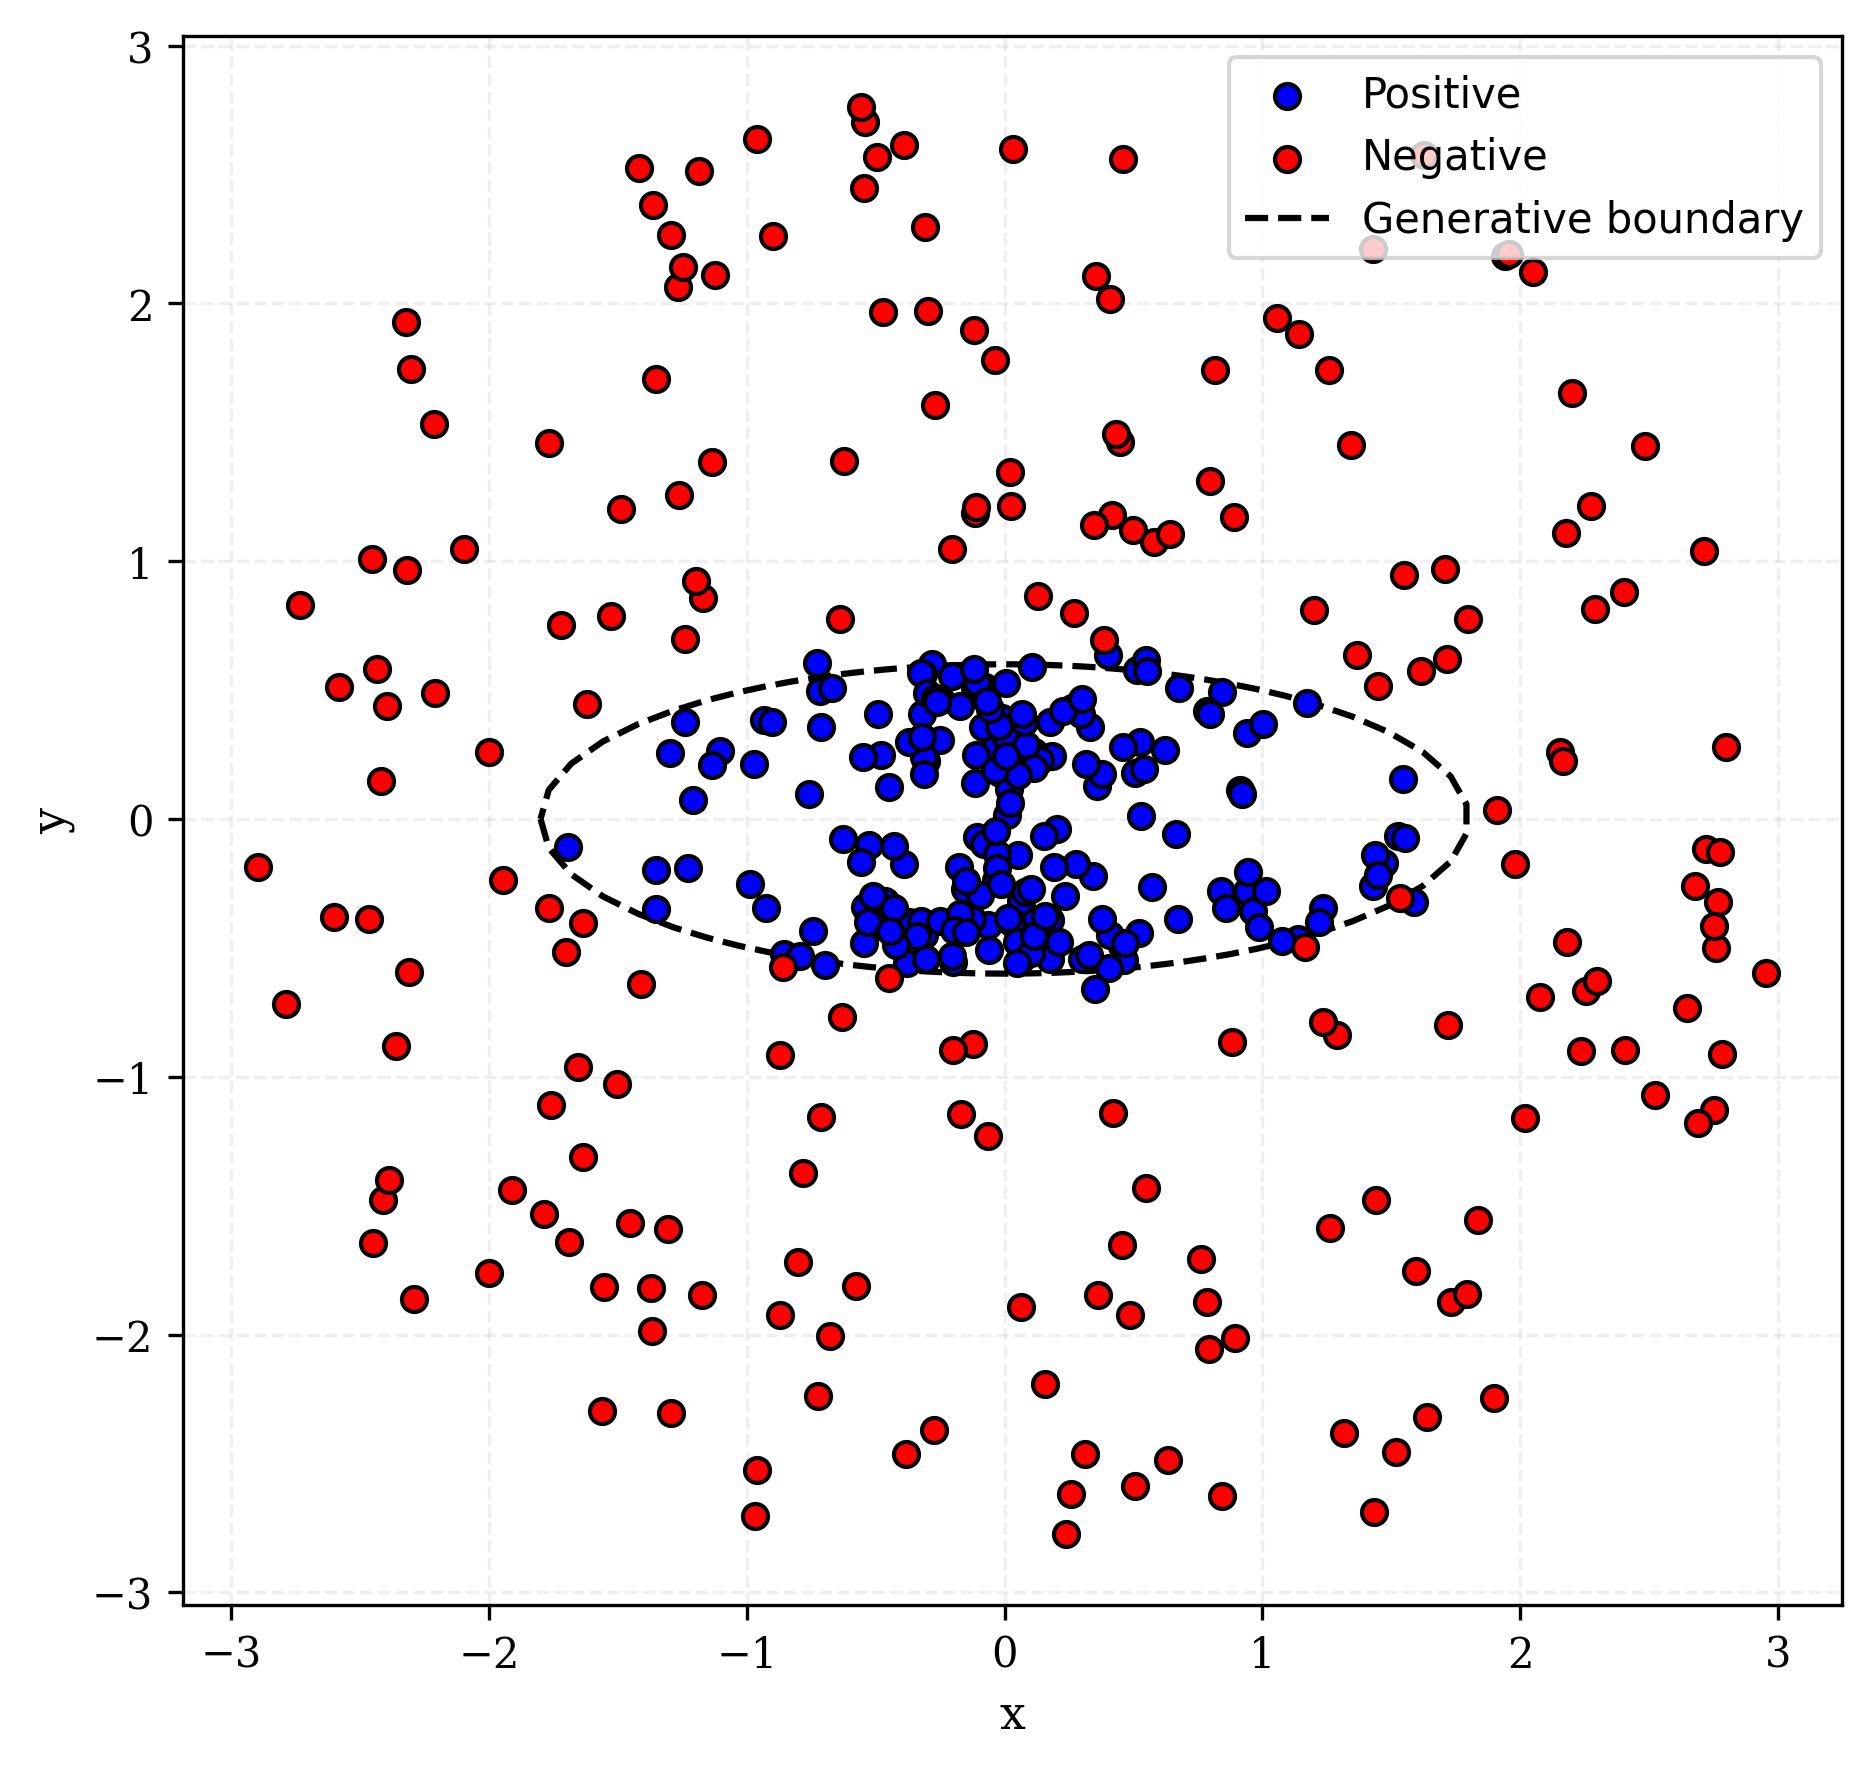

In [50]:
elliptic_fig, elliptic_ax = plot_in_rectangular_coordinates(
    synth_cartesian_dataset.X, 
    synth_cartesian_dataset.y,
    title=""
)

Thetas = np.linspace(-np.pi, np.pi, 100)
Rs = (a*b)/(np.sqrt((b*np.cos(Thetas))**2 + (a*np.sin(Thetas))**2))
elliptic_ax.plot(Rs*np.cos(Thetas), Rs*np.sin(Thetas), color='black', linestyle='--', label='Generative boundary')
elliptic_ax.legend()
elliptic_ax.set_aspect('equal')

display(elliptic_fig)

In [51]:
plot_manager.handle(elliptic_fig, name='sample_synthetic_elliptical_dataset')

In [52]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(x1=synth_cartesian_dataset.X['x'], x2=synth_cartesian_dataset.X['y'], resolution=500)
grid_cartesian = grid_cartesian.rename(columns={'x1': 'x', 'x2': 'y'})

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_cartesian)

# Transform polar into curvilinear grid
grid_r2cos2_sqd = pd.DataFrame({'r^2': grid_polar['r']**2, 'cos^2()': np.cos(grid_polar['theta'])**2})

In [53]:
TP_ref = len(synth_polar_dataset.X[(synth_polar_dataset.X['r']<=gen_rbound_func(synth_polar_dataset.X['theta'])) & (synth_polar_dataset.y==1)])
TN_ref = len(synth_polar_dataset.X[(synth_polar_dataset.X['r']>gen_rbound_func(synth_polar_dataset.X['theta'])) & (synth_polar_dataset.y==0)])

reference_metrics = {
    'accuracy': (TP_ref + TN_ref)/(2*num_class_points),
    'precision': TP_ref/(TP_ref + (num_class_points-TN_ref)),
    'recall': TP_ref/(num_class_points)
}
reference_metrics['f1'] = 2 * (reference_metrics['precision'] * reference_metrics['recall']) / (reference_metrics['precision'] + reference_metrics['recall'])
metrics_df = pd.DataFrame(reference_metrics, index=['Generator decision boundary'])
display(metrics_df)

,accuracy,precision,recall,f1
Generator decision boundary,0.9725,0.994764,0.95,0.971867


### Logistic Regression on Polar Data

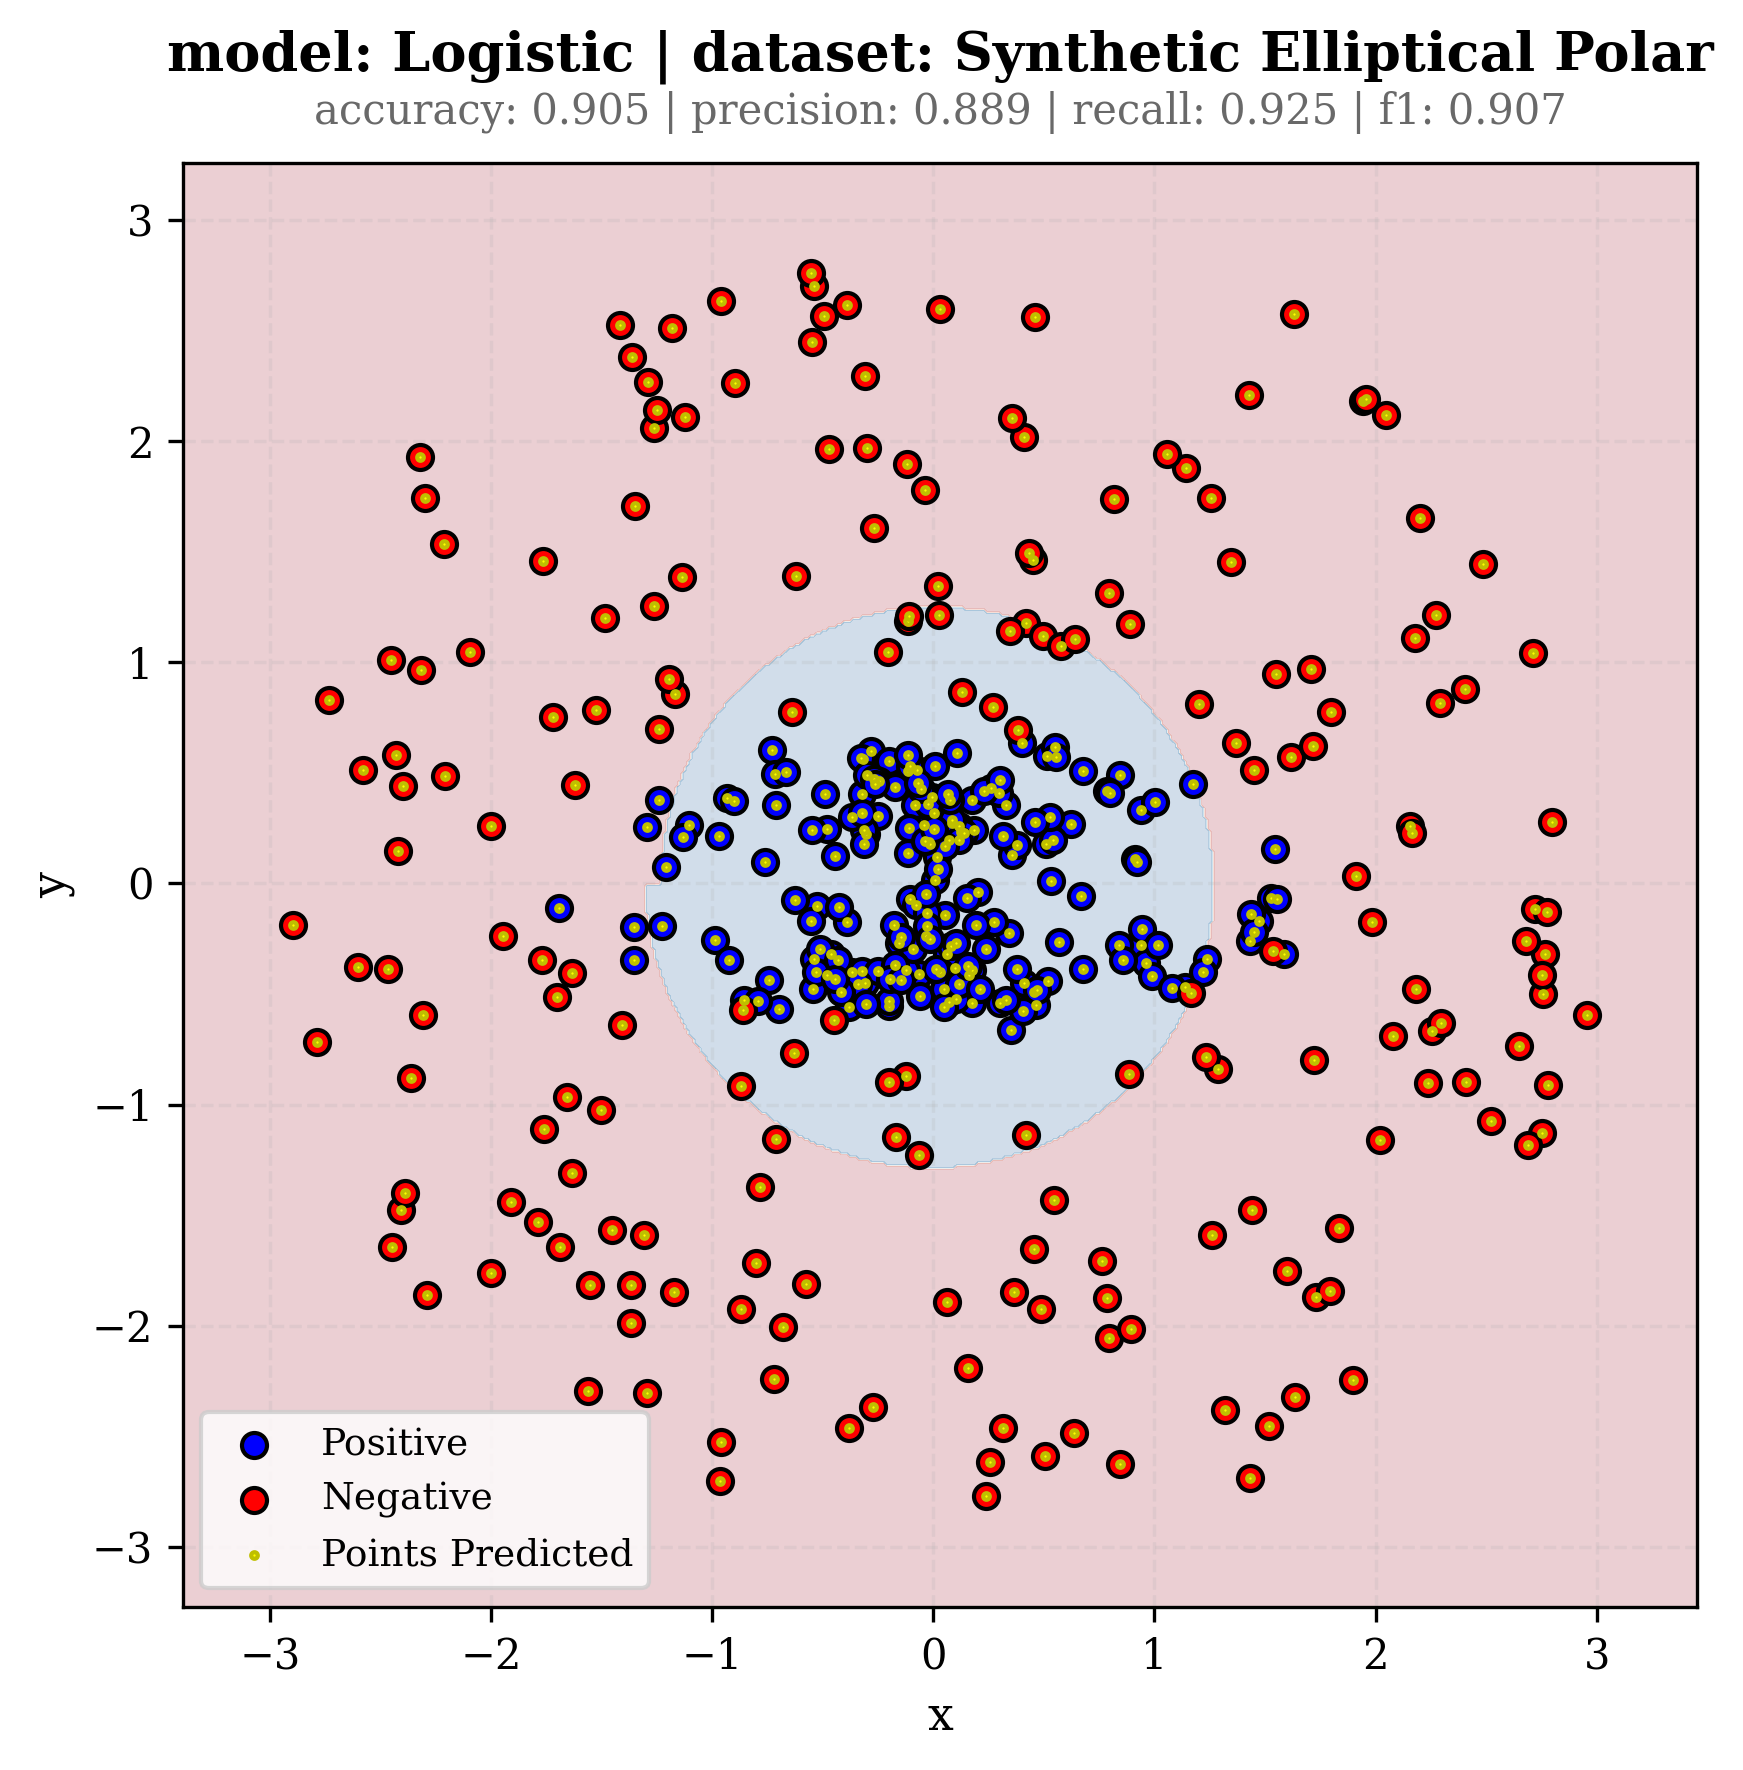

In [54]:
lr_model = LogisticRegression(random_state=random_state)
lr_model.fit(synth_polar_dataset.X, synth_polar_dataset.y)
lr_metrics = ModelMetrics('Logistic Regression', 'Polar', synth_polar_dataset.y, lr_model.predict(synth_polar_dataset.X))
lr_metrics.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metrics.to_pandas().rename(index={0:'Logistic | Polar'})])

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Elliptical Polar',
    metrics=lr_metrics.to_dict()
)

lr_ax.set_aspect('equal')
display(lr_fig)

In [55]:
plot_manager.handle(lr_fig, name='logi_regr_polar_synthetic_elliptical_dataset')

### Logistic Regression on Custom Curvilinear Coordinates

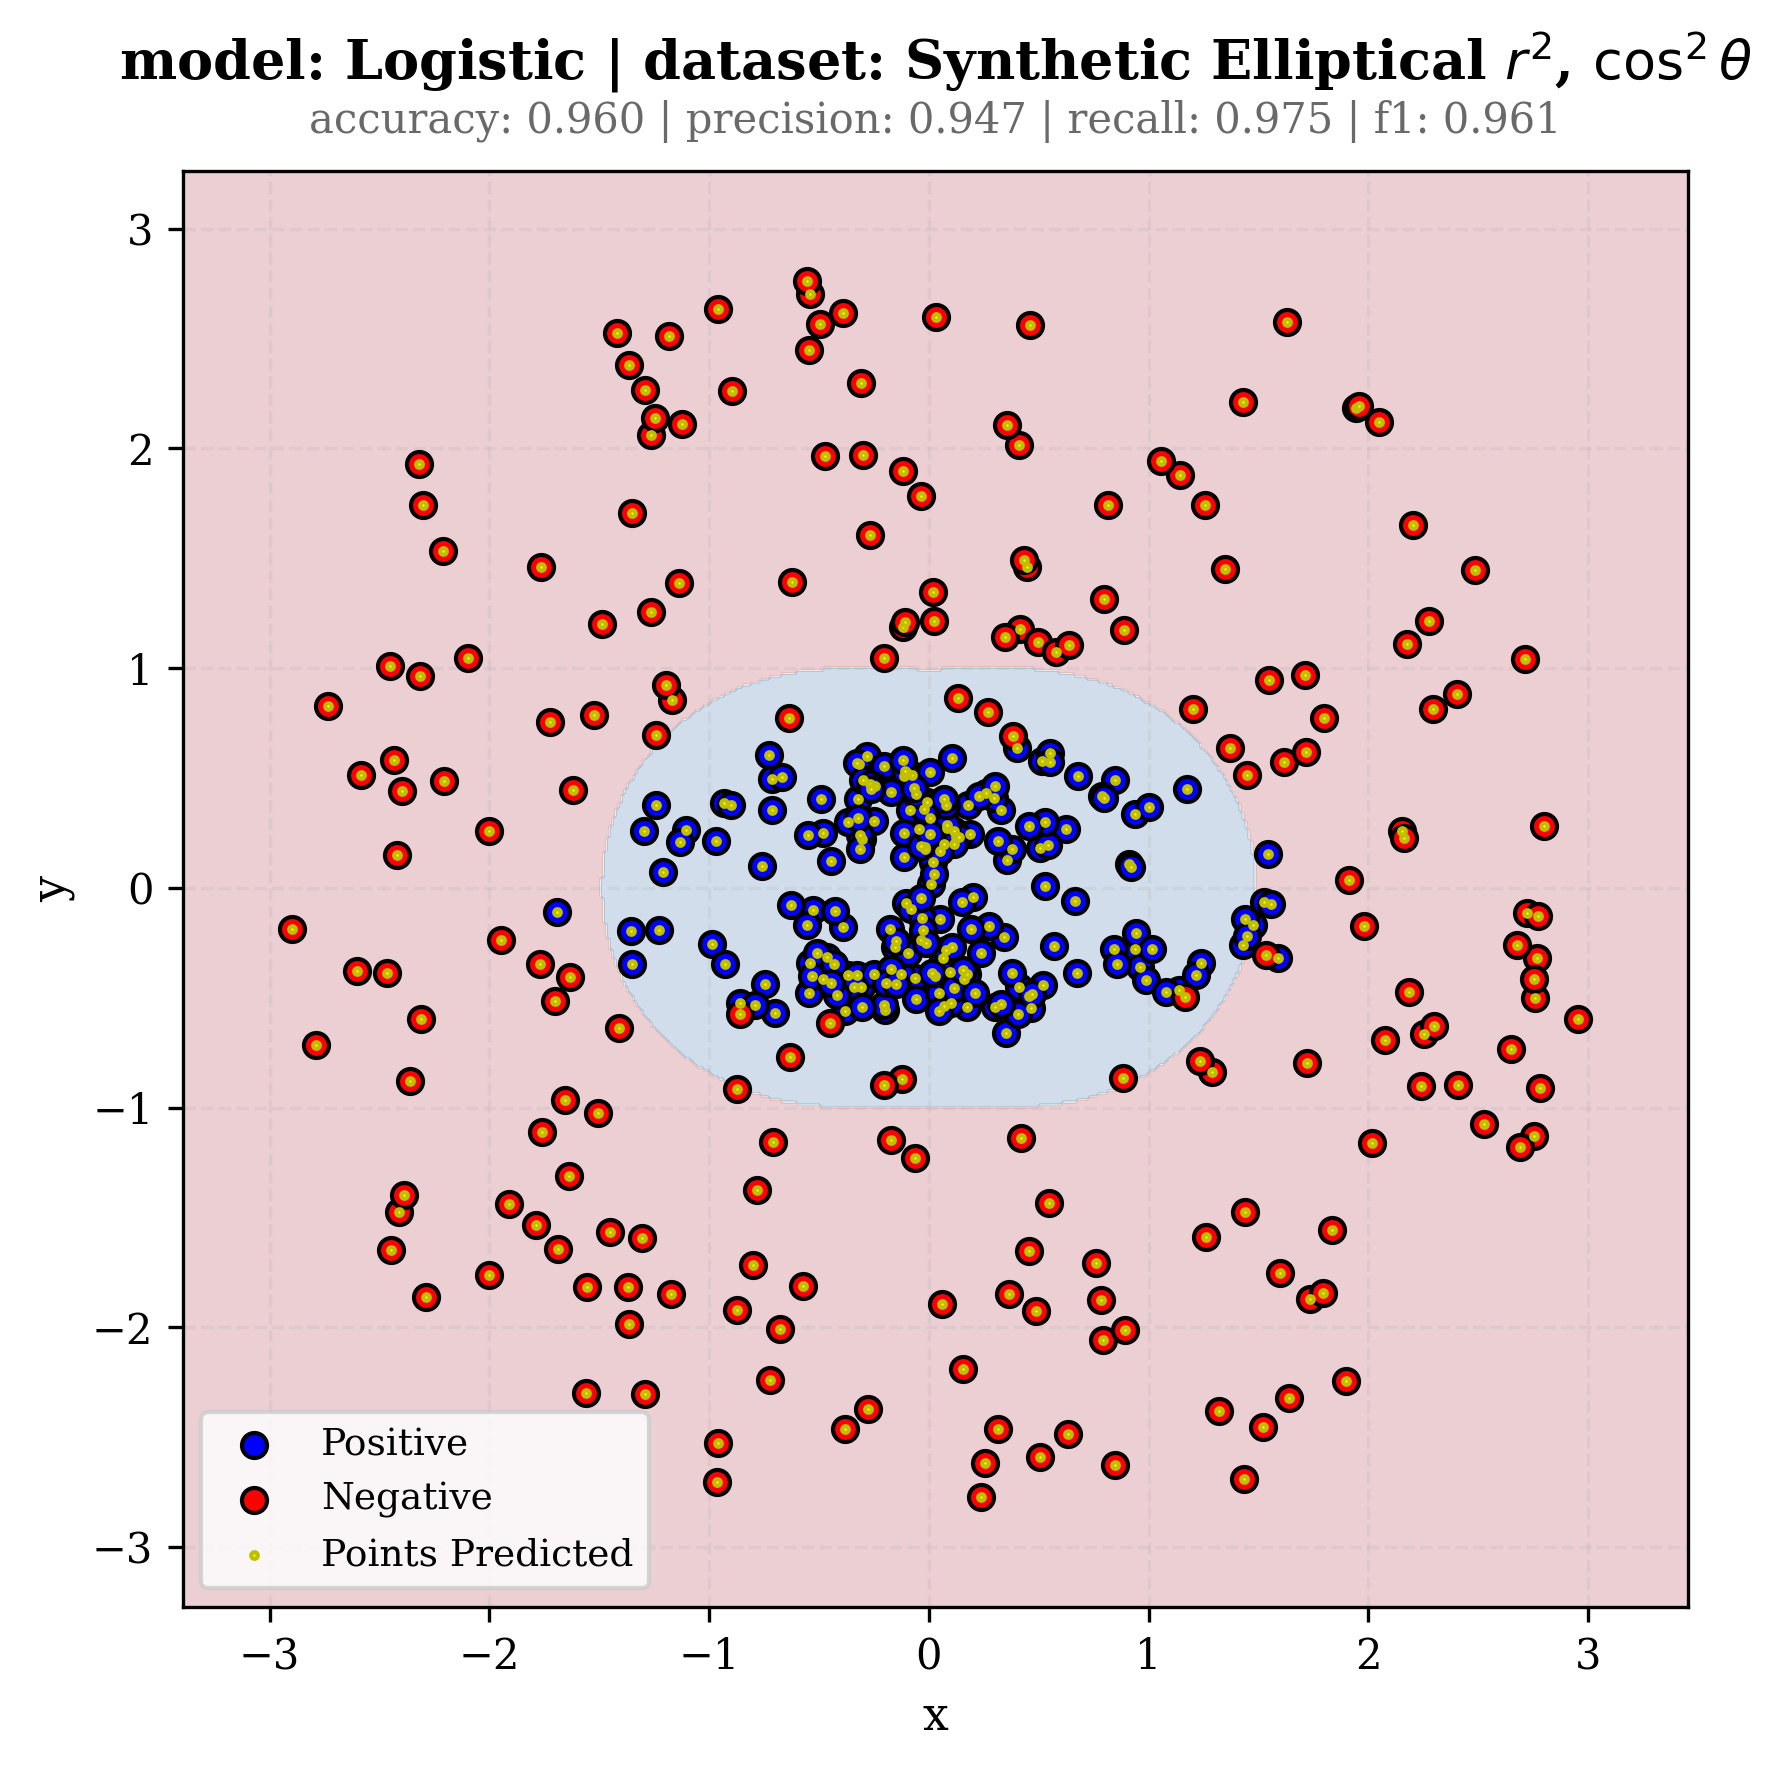

In [56]:
lr_model_r2cos2 = LogisticRegression(random_state=random_state)
lr_model_r2cos2.fit(synth_r2cos2_dataset.X, synth_r2cos2_dataset.y)
lr_metrics_r2cos2 = ModelMetrics('Logistic Regression', 'r^2,cos2()', synth_r2cos2_dataset.y, lr_model_r2cos2.predict(synth_r2cos2_dataset.X))
lr_metrics_r2cos2.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metrics_r2cos2.to_pandas().rename(index={0:'Logistic | Curvilinear Approximate'})])

dataset_label = r'$\cos^2{\theta}$'

lr_r2cos2_fig, lr_r2cos2_ax = plot_decision_boundary(
    model=lr_model_r2cos2, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_r2cos2_sqd, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Elliptical $r^2$, {dataset_label}',
    metrics=lr_metrics_r2cos2.to_dict()
)

lr_r2cos2_ax.set_aspect('equal')
display(lr_r2cos2_fig)

In [57]:
plot_manager.handle(lr_r2cos2_fig, name='logi_regr_curvilinear_synthetic_elliptical_dataset')

### SVM

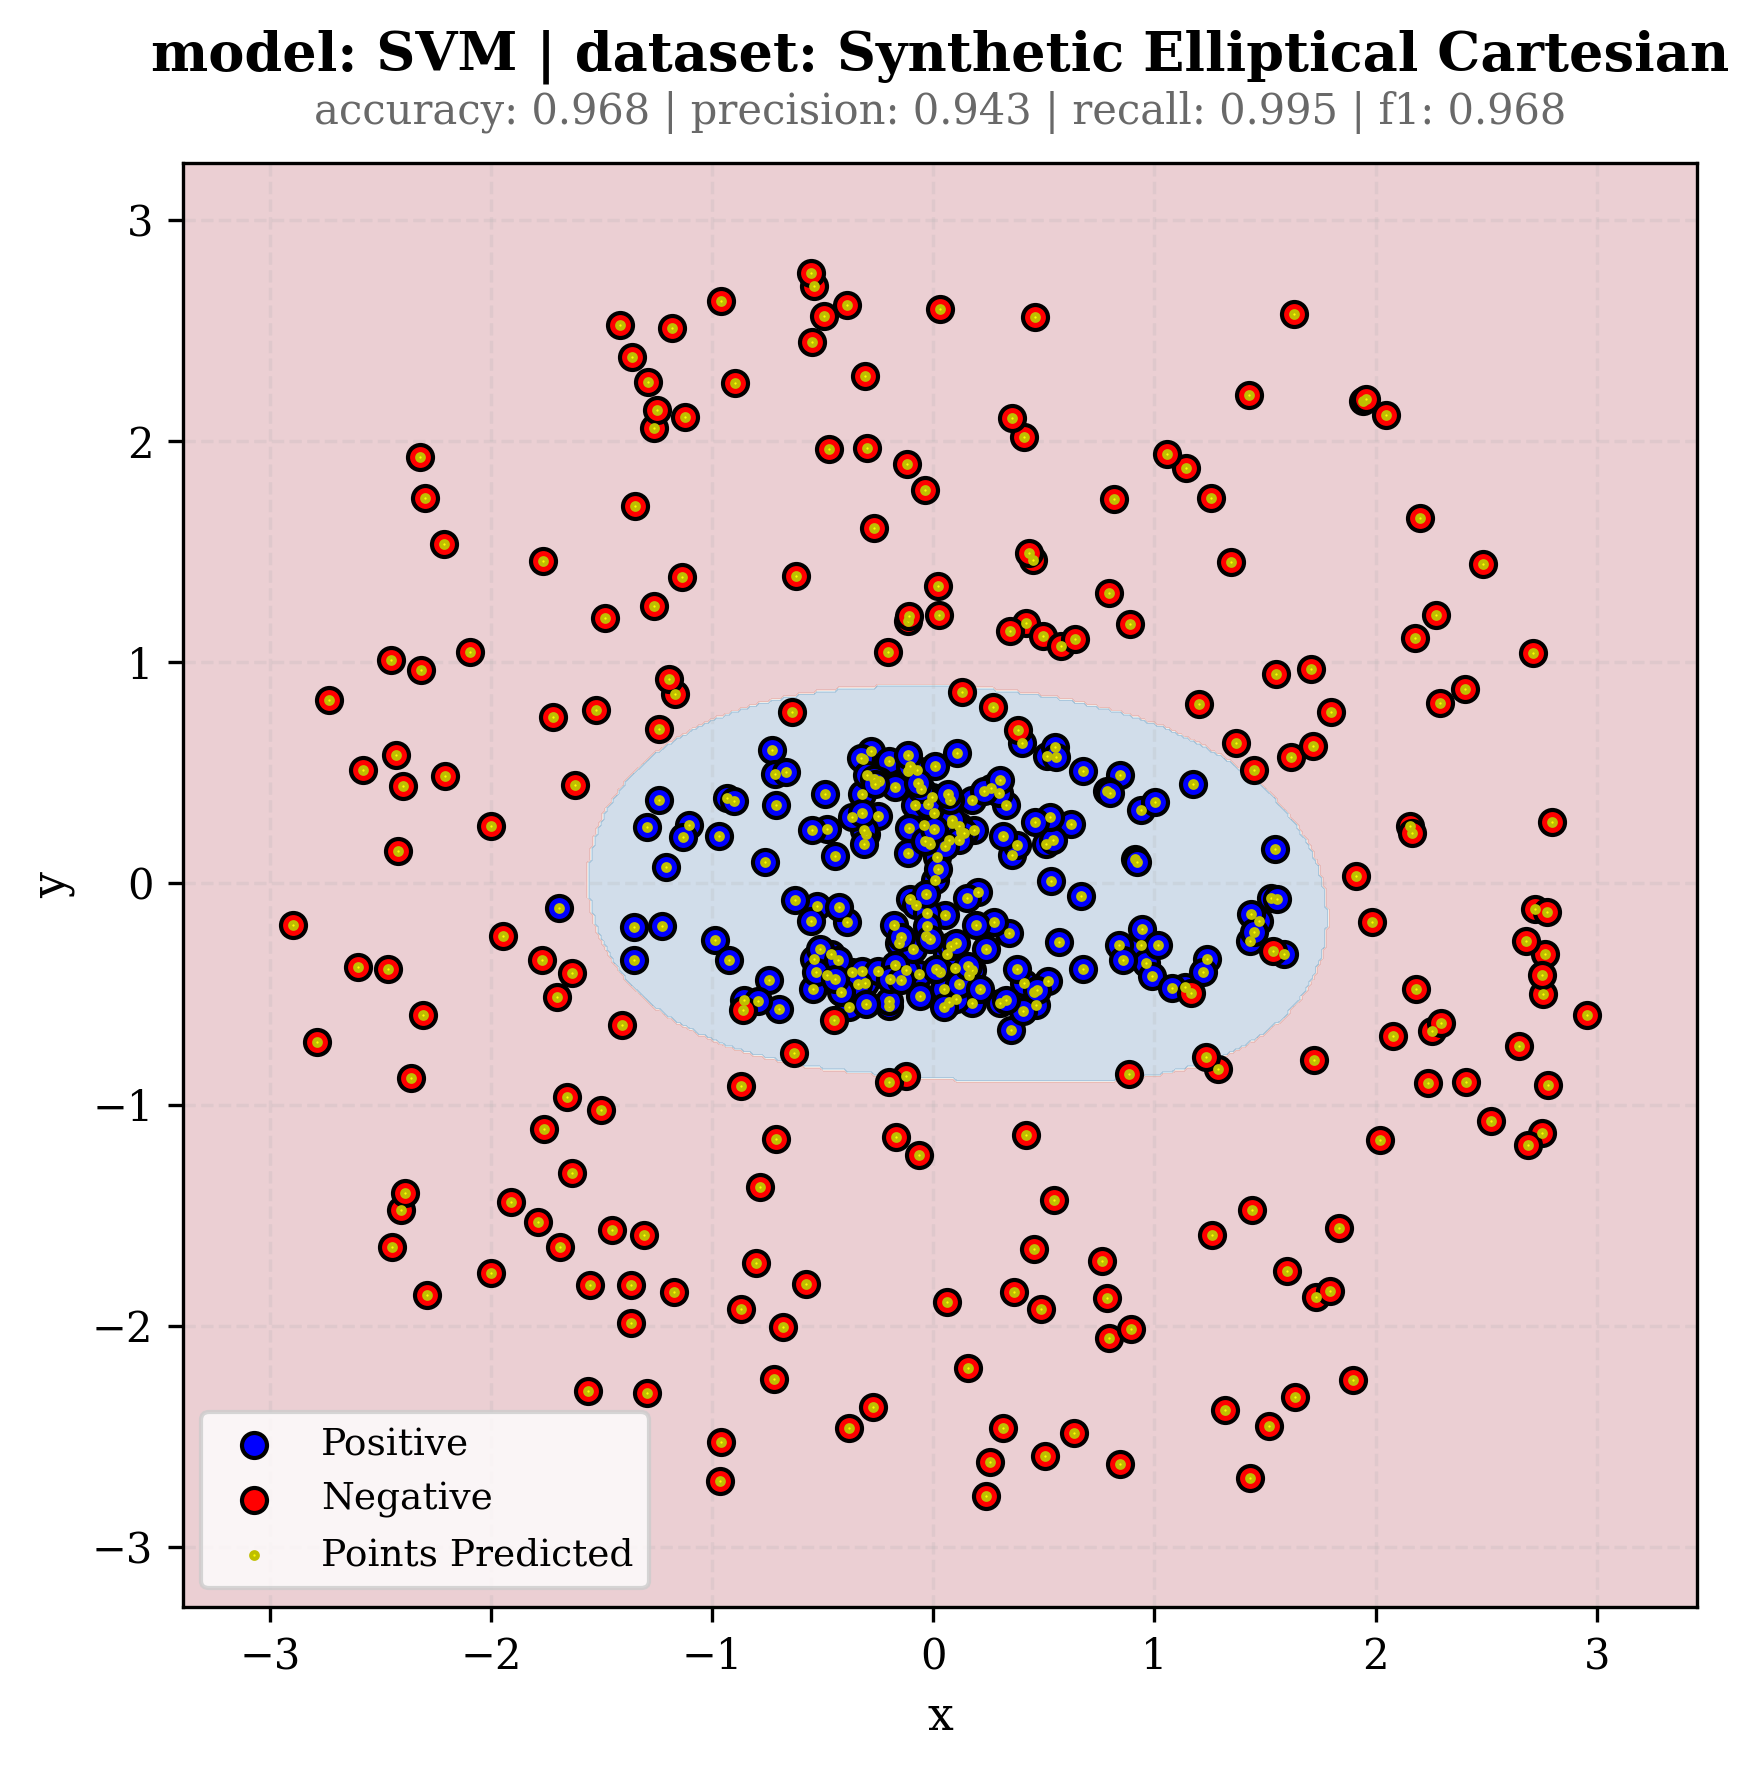

In [58]:
svm_model = SVC(kernel='rbf', random_state=random_state)
svm_model.fit(synth_cartesian_dataset.X, synth_cartesian_dataset.y)
svm_metrics = ModelMetrics('SVM', 'Cartesian', synth_cartesian_dataset.y, svm_model.predict(synth_cartesian_dataset.X))
svm_metrics.compute_metrics()
metrics_df = pd.concat([metrics_df, svm_metrics.to_pandas().rename(index={0:'SVM | Cartesian'})])

svm_fig, svm_ax = plot_decision_boundary(
    model=svm_model, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Synthetic Elliptical Cartesian',
    metrics=svm_metrics.to_dict()
)

svm_ax.set_aspect('equal')
display(svm_fig)

In [59]:
plot_manager.handle(svm_fig, name='svm_synthetic_elliptical_dataset')

### General Quadratic Form of Ellipse

In [60]:
# Transform cartesian into quadratic grid
grid_quad = pd.DataFrame({'x^2': grid_cartesian['x']**2, 'y^2': grid_cartesian['y']**2, 'xy': grid_cartesian['x']*grid_cartesian['y'], 'x': grid_cartesian['x'], 'y': grid_cartesian['y']})

# Transform data points from cartesian into quadratic form
synth_quad_dataset = synth_cartesian_dataset.transform(
    lambda df: pd.DataFrame({'x^2': df['x']**2, 'y^2': df['y']**2, 'xy': df['x']*df['y'], 'x': df['x'], 'y': df['y']})
)

/Users/albertops/.pyenv/versions/feature-representation-vs-model-complexity/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


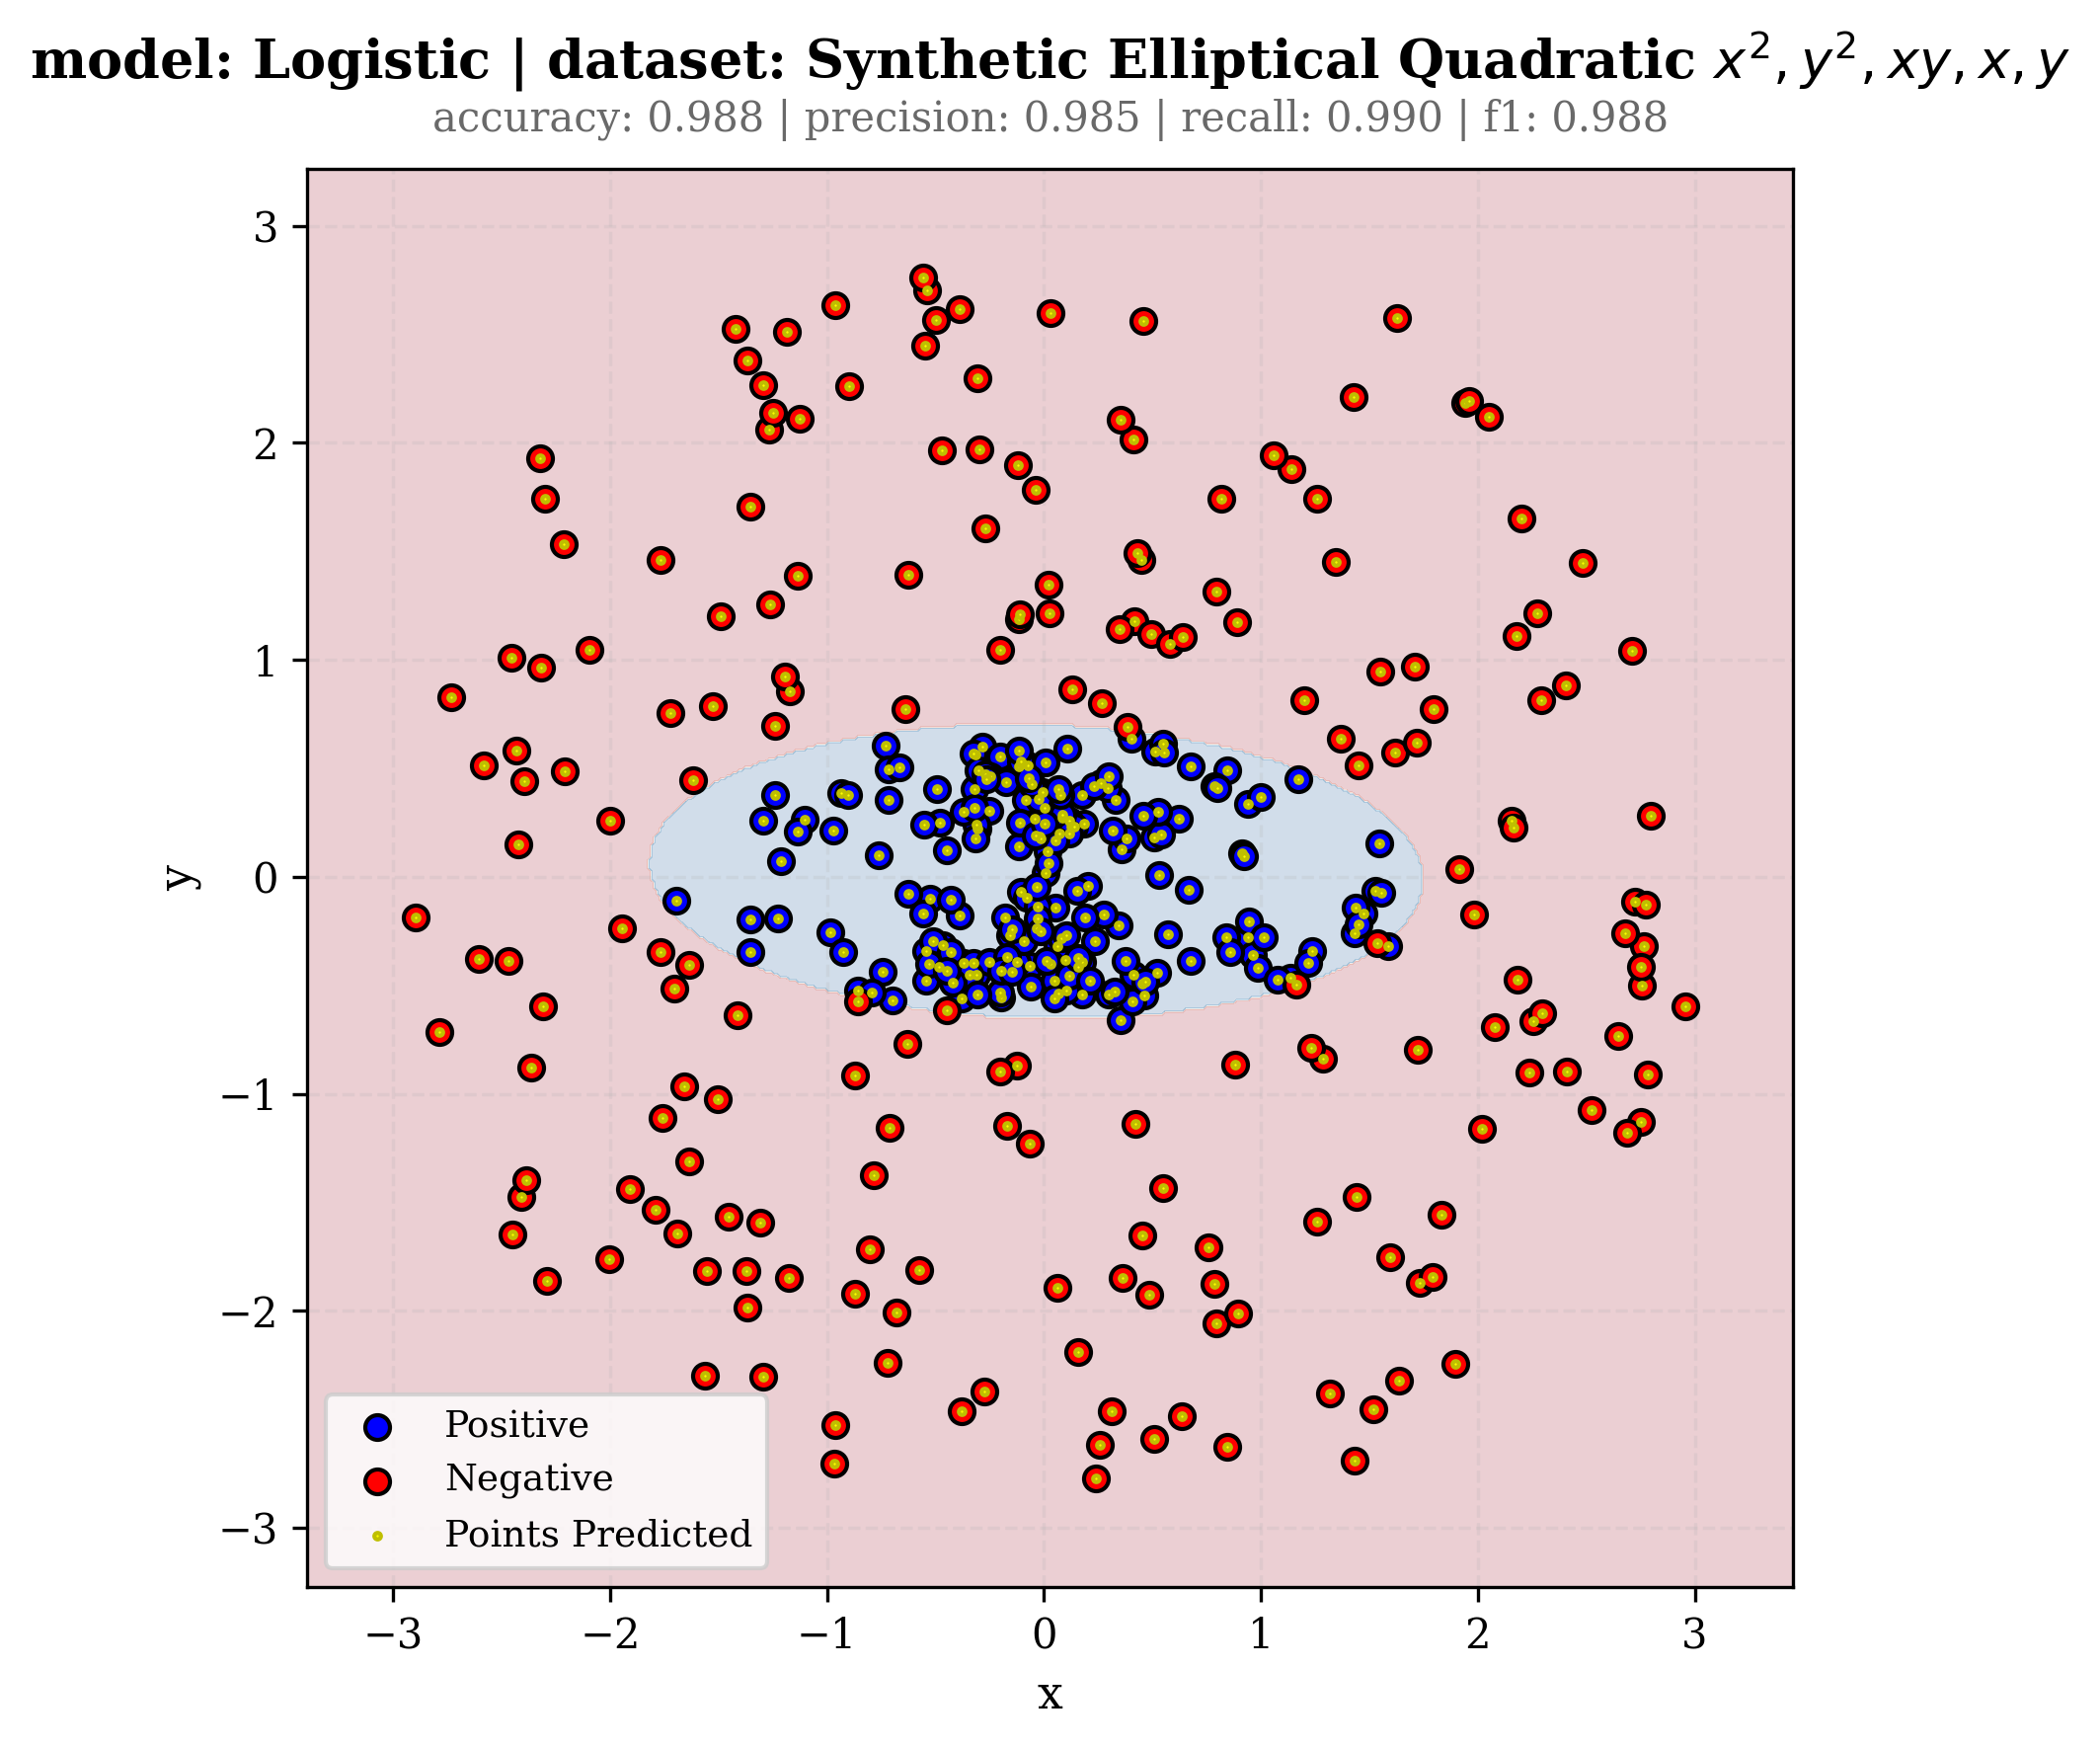

In [61]:
quad_model = LogisticRegression(penalty=None, random_state=random_state)
quad_model.fit(synth_quad_dataset.X, synth_quad_dataset.y)
quad_metrics = ModelMetrics('Logistic Regression', 'Quadratic', synth_quad_dataset.y, quad_model.predict(synth_quad_dataset.X))
quad_metrics.compute_metrics()
metrics_df = pd.concat([metrics_df, quad_metrics.to_pandas().rename(index={0:'Logistic | Quadratic Cartesian'})])

quad_fig, quad_ax = plot_decision_boundary(
    model=quad_model, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_quad, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Elliptical Quadratic $x^2,y^2,xy,x,y$',
    metrics=quad_metrics.to_dict()
)

quad_ax.set_aspect('equal')
display(quad_fig)

In [62]:
plot_manager.handle(quad_fig, name='logi_regr_quad_synthetic_elliptical_dataset')

### Summary

In [63]:
display(metrics_df.loc[~metrics_df.index.duplicated(keep='last')])

,accuracy,precision,recall,f1
Generator decision boundary,0.9725,0.994764,0.950,0.971867
Logistic | Polar,0.9050,0.889423,0.925,0.906863
Logistic | Curvilinear Approximate,0.9600,0.946602,0.975,0.960591
SVM | Cartesian,0.9675,0.943128,0.995,0.968370
Logistic | Quadratic Cartesian,0.9875,0.985075,0.990,0.987531


# Non-radially Symmetrical Data

In [64]:
synth_non_rad_polar_neg_dataset1 = generate_custom_polar_dataset(
    label=0,
    num_points=50,
    theta_lb=-np.pi/2,
    theta_ub=-np.pi/4,
    theta_pdf=lambda low, high, size: np.random.uniform(low, high, size)
)
synth_non_rad_polar_neg_dataset2 = generate_custom_polar_dataset(
    label=0,
    num_points=50,
    theta_lb=np.pi/2,
    theta_ub=3*np.pi/4,
    theta_pdf=lambda low, high, size: np.random.uniform(low, high, size)
    
)
synth_non_rad_polar_neg_dataset = PointsDataset.merge_dataset(synth_non_rad_polar_neg_dataset1, synth_non_rad_polar_neg_dataset2)

synth_non_rad_polar_pos_dataset1 = generate_custom_polar_dataset(
    label=1,
    num_points=50,
    theta_lb=-np.pi,
    theta_ub=-np.pi/2,
    theta_pdf=lambda low, high, size: np.random.uniform(low, high, size),
    r_inner_bound_func=lambda theta: 0.2 * np.cos(theta)**2,
    r_outer_bound_func=lambda theta: 0.6 + 0.2 * np.cos(theta)**2,
    r_pdf=lambda low, high: np.random.uniform(low, high)
)
synth_non_rad_polar_pos_dataset2 = generate_custom_polar_dataset(
    label=1,
    num_points=50,
    theta_lb=-np.pi/4,
    theta_ub=np.pi/2,
    theta_pdf=lambda low, high, size: np.random.uniform(low, high, size),
    r_inner_bound_func=lambda theta: 0.2 * np.cos(theta)**2,
    r_outer_bound_func=lambda theta: 0.6 + 0.2 * np.cos(theta)**2,
    r_pdf=lambda low, high: np.random.uniform(low, high)
)
synth_non_rad_polar_pos_dataset = PointsDataset.merge_dataset(synth_non_rad_polar_pos_dataset1, synth_non_rad_polar_pos_dataset2)

synth_non_rad_polar_dataset = PointsDataset.merge_dataset(synth_non_rad_polar_neg_dataset, synth_non_rad_polar_pos_dataset)
synth_non_rad_cartesian_dataset = synth_non_rad_polar_dataset.transform(polar_to_cartesian)
synth_non_rad_r2cos2_dataset = synth_non_rad_polar_dataset.transform(polar_to_curvilinear_r2cos2theta)

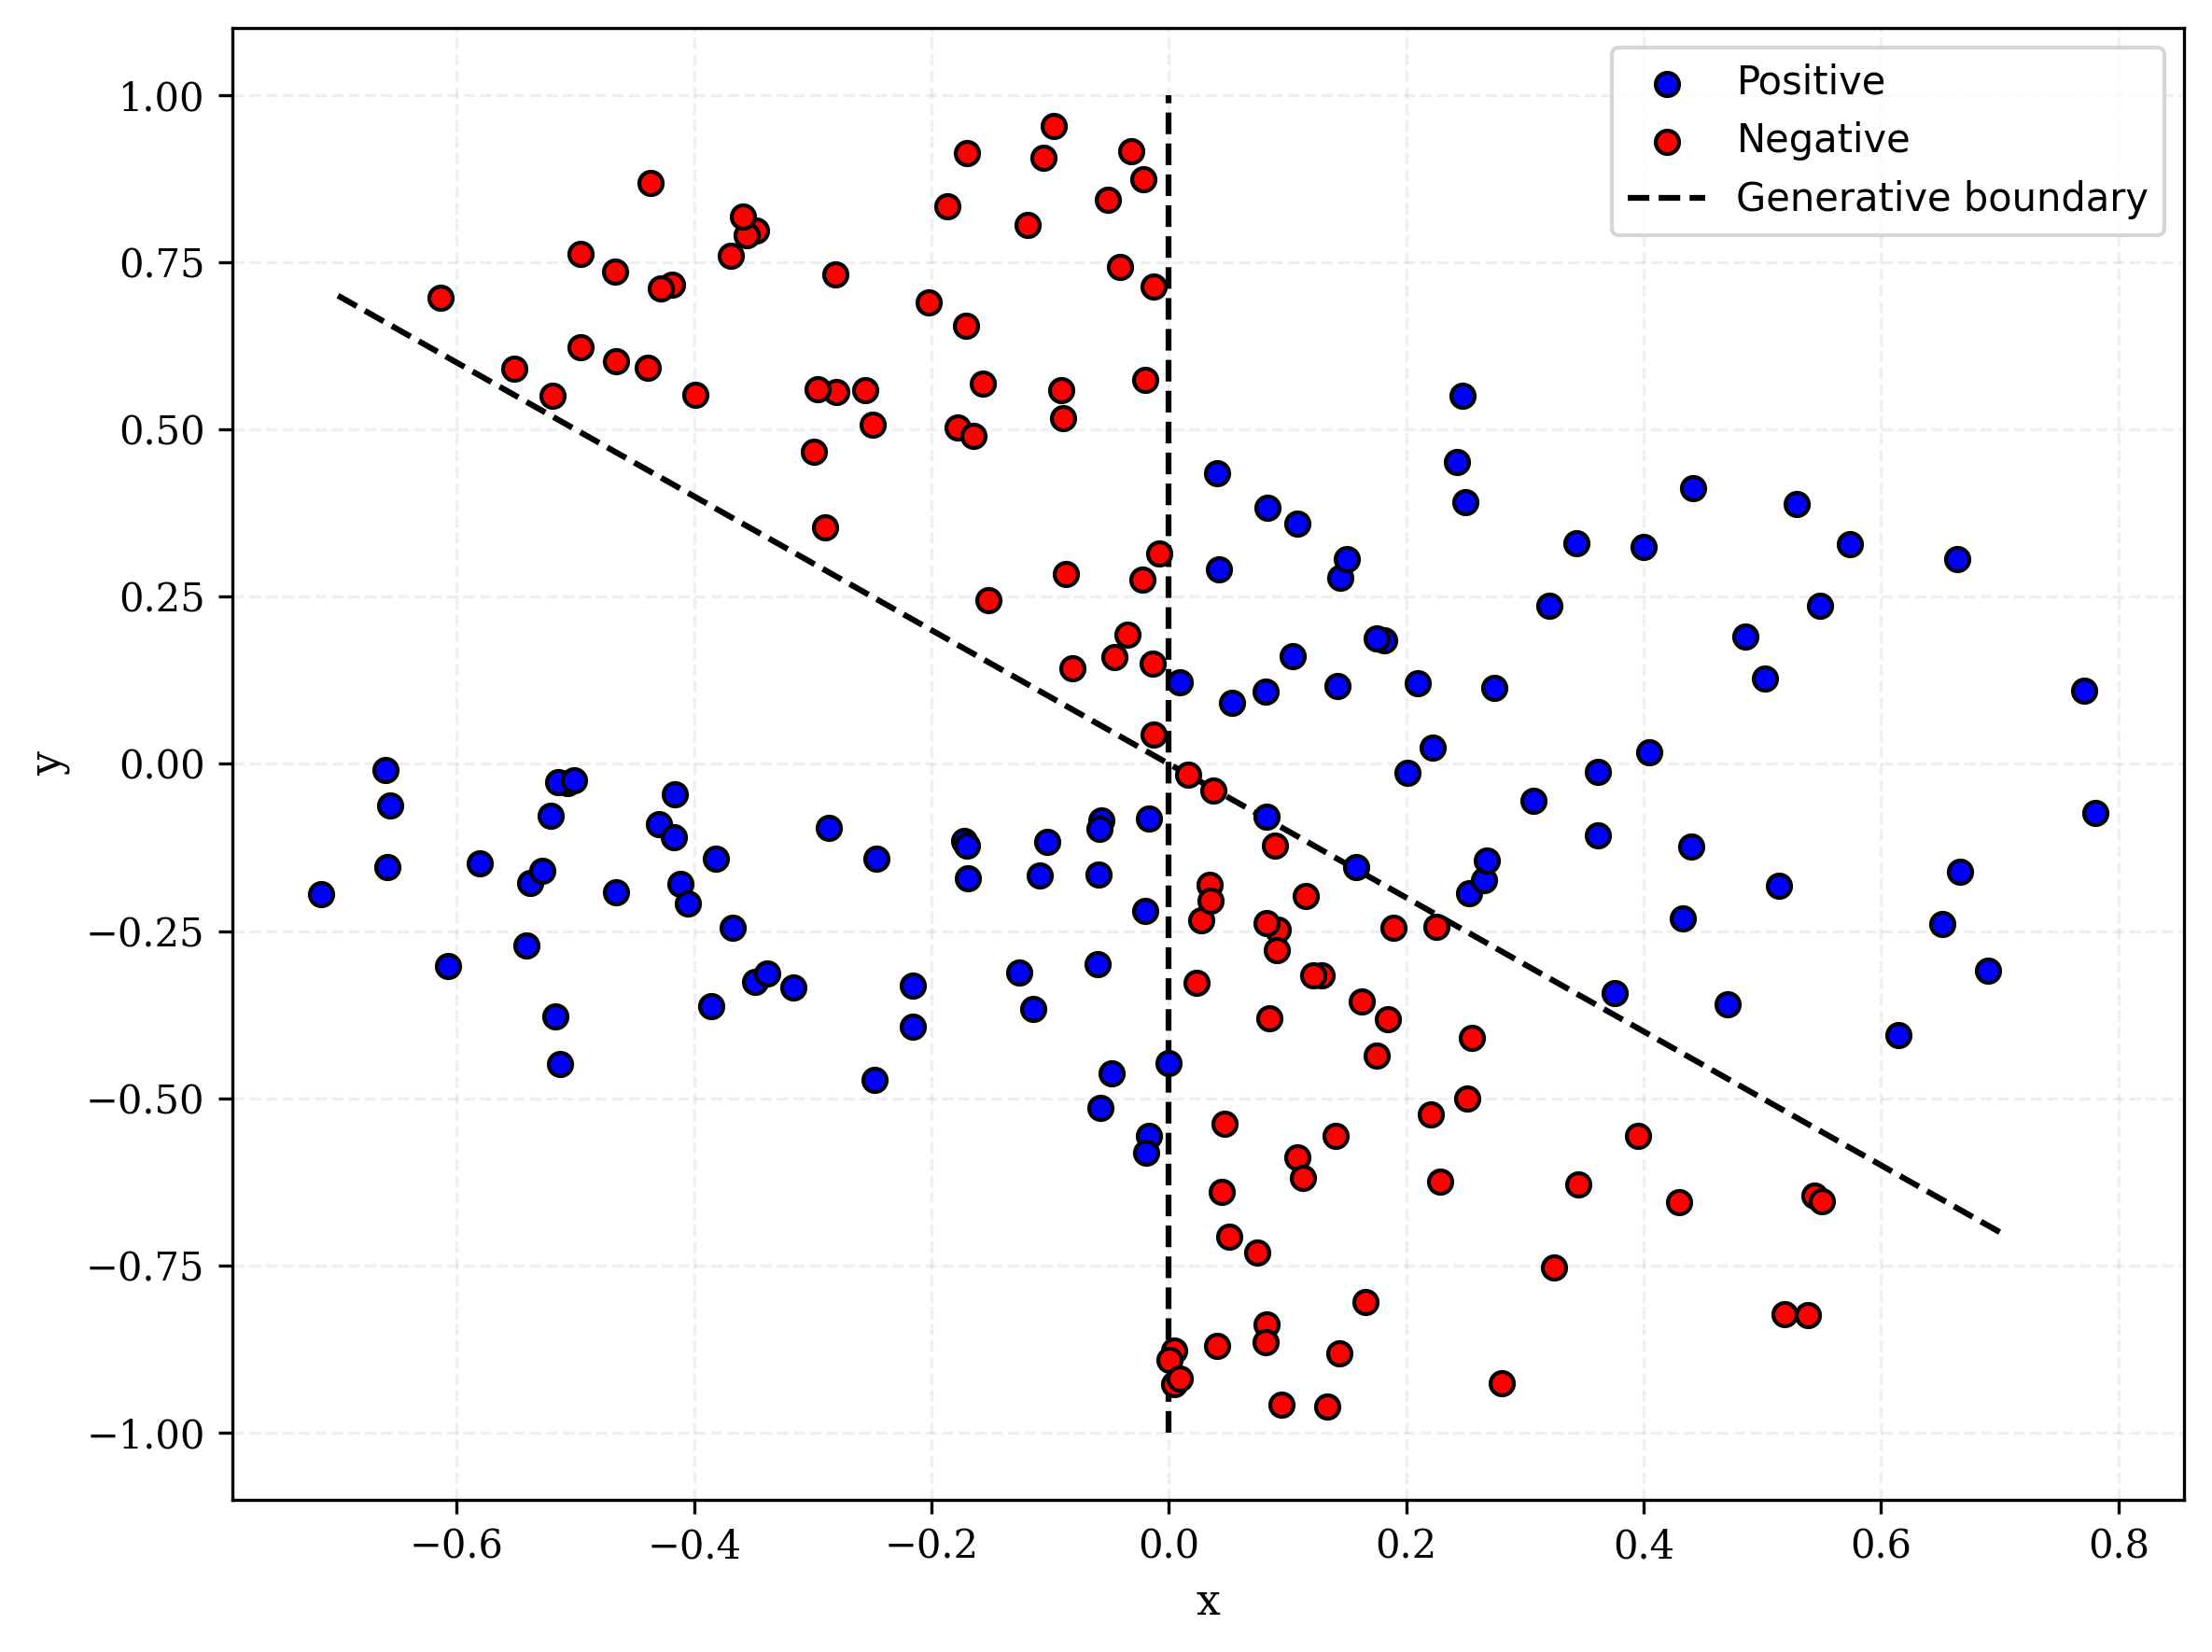

In [65]:
non_rad_fig, non_rad_ax = plot_in_rectangular_coordinates(
    synth_non_rad_cartesian_dataset.X, 
    synth_non_rad_cartesian_dataset.y,
    title=""
)

non_rad_ax.plot(np.zeros(100), np.linspace(-1, 1, 100), color='black', linestyle='--', label='Generative boundary')
non_rad_ax.plot(np.linspace(-0.7, 0.7, 100), -np.linspace(-0.7, 0.7, 100), color='black', linestyle='--')
non_rad_ax.legend()

display(non_rad_fig)

In [66]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(x1=synth_non_rad_cartesian_dataset.X['x'], x2=synth_non_rad_cartesian_dataset.X['y'], resolution=500)
grid_cartesian = grid_cartesian.rename(columns={'x1': 'x', 'x2': 'y'})

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_cartesian)

# Transform polar into curvilinear grid
grid_r2cos2_sqd = pd.DataFrame({'r^2': grid_polar['r']**2, 'cos^2()': np.cos(grid_polar['theta'])**2})

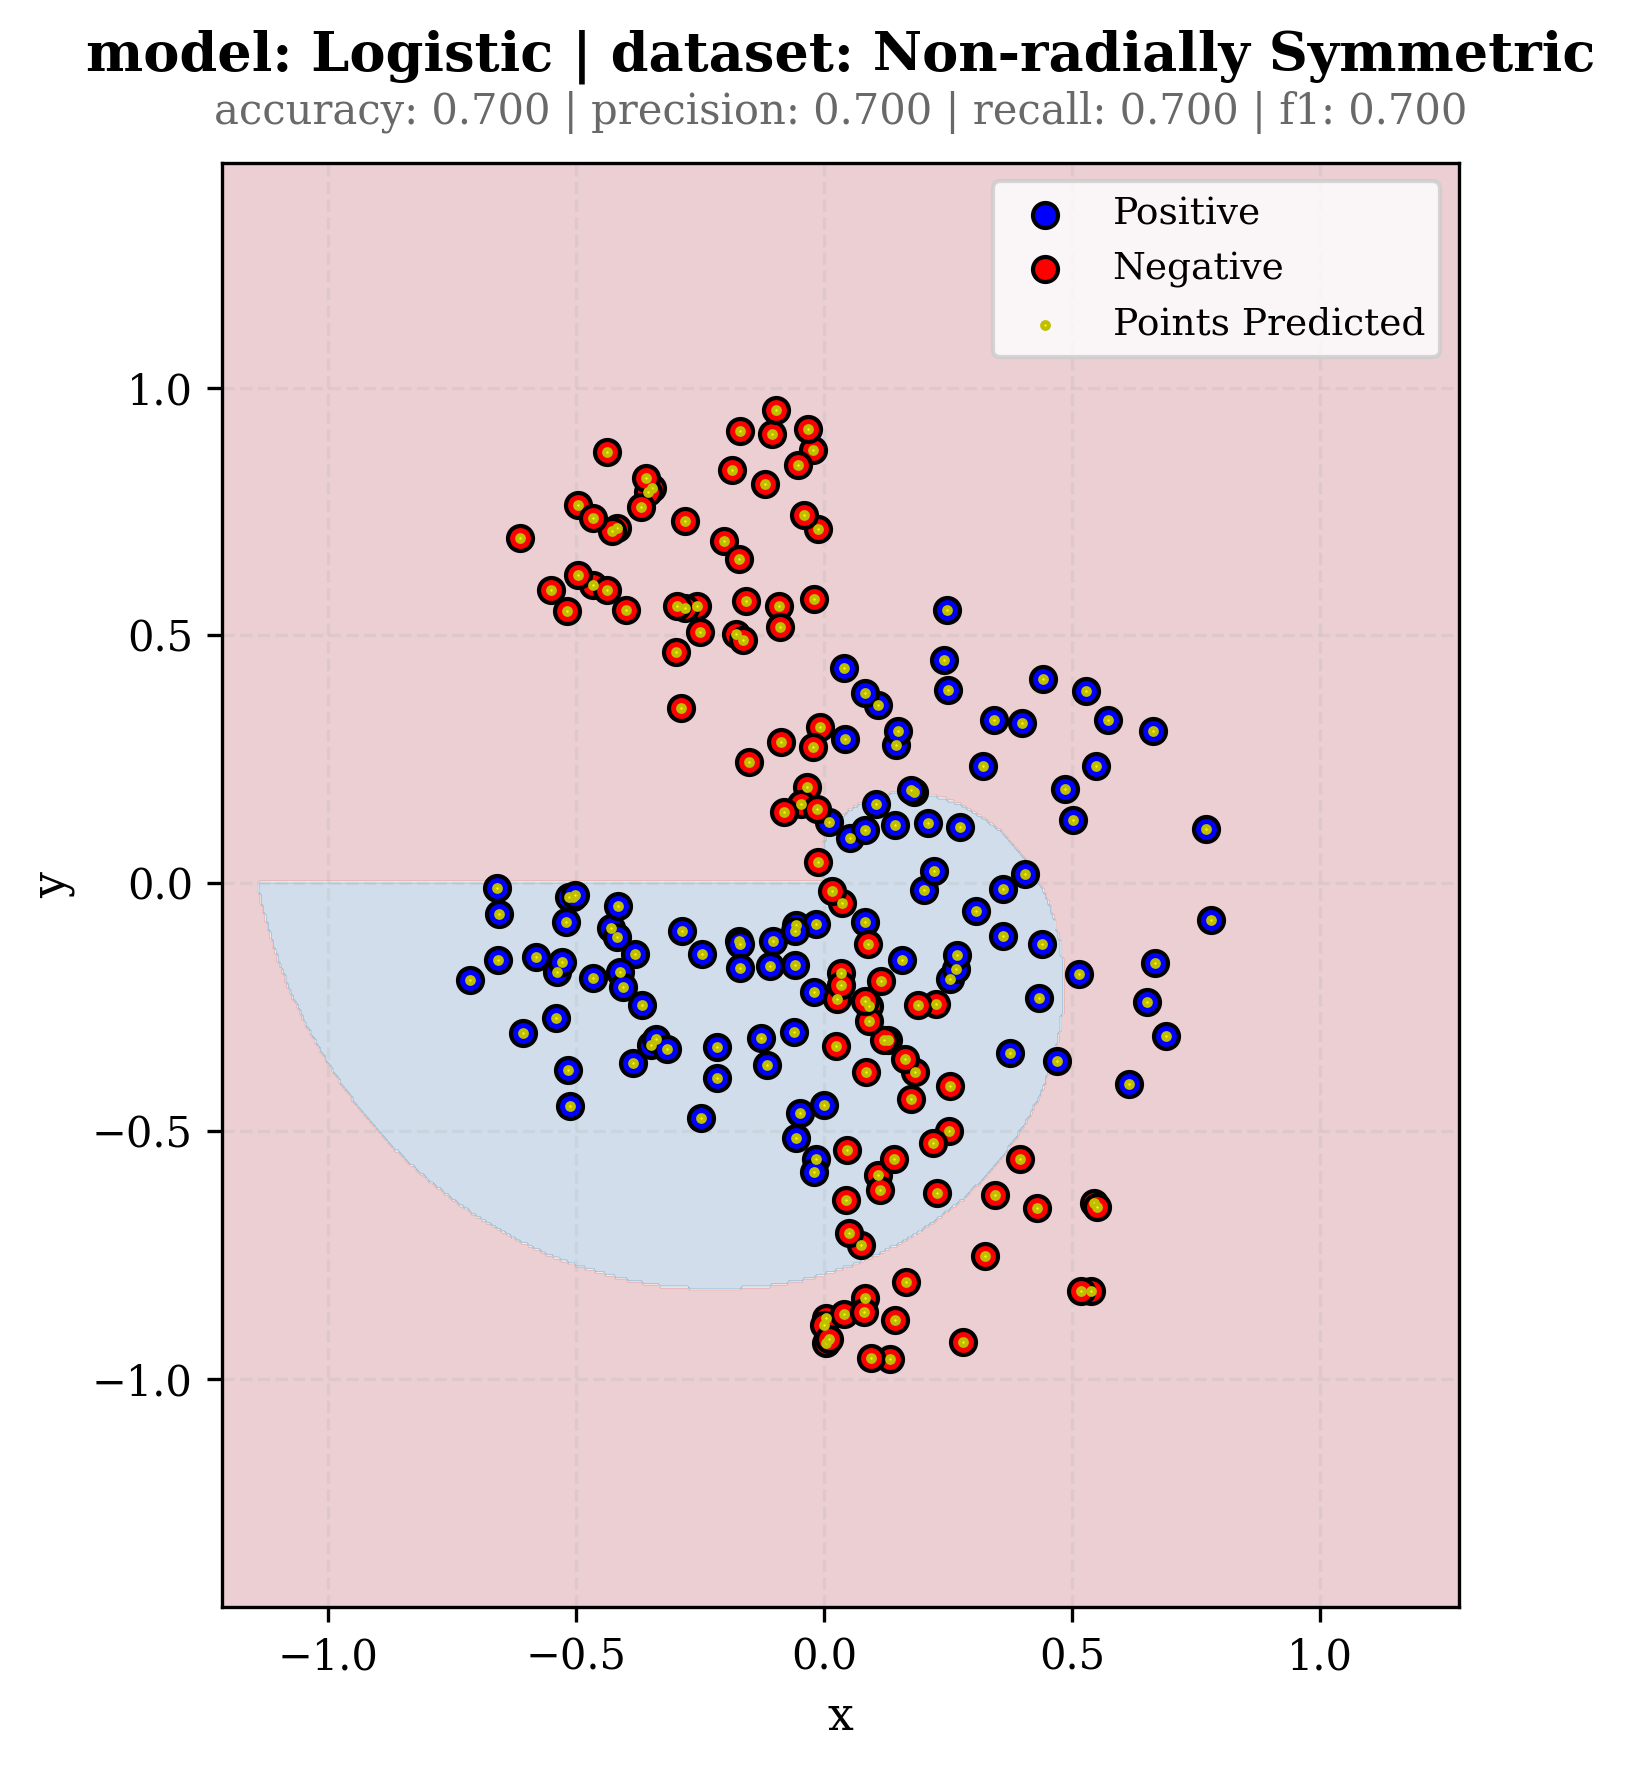

In [67]:
lr_model = LogisticRegression(random_state=random_state)
lr_model.fit(synth_non_rad_polar_dataset.X, synth_non_rad_polar_dataset.y)
lr_metrics = ModelMetrics('Logistic Regression', 'Non-radially Symmetric', synth_non_rad_polar_dataset.y, lr_model.predict(synth_non_rad_polar_dataset.X))
lr_metrics.compute_metrics()

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model, dataset_X=synth_non_rad_cartesian_dataset.X, dataset_y=synth_non_rad_cartesian_dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Non-radially Symmetric',
    metrics=lr_metrics.to_dict()
)

lr_ax.set_aspect('equal')
display(lr_fig)

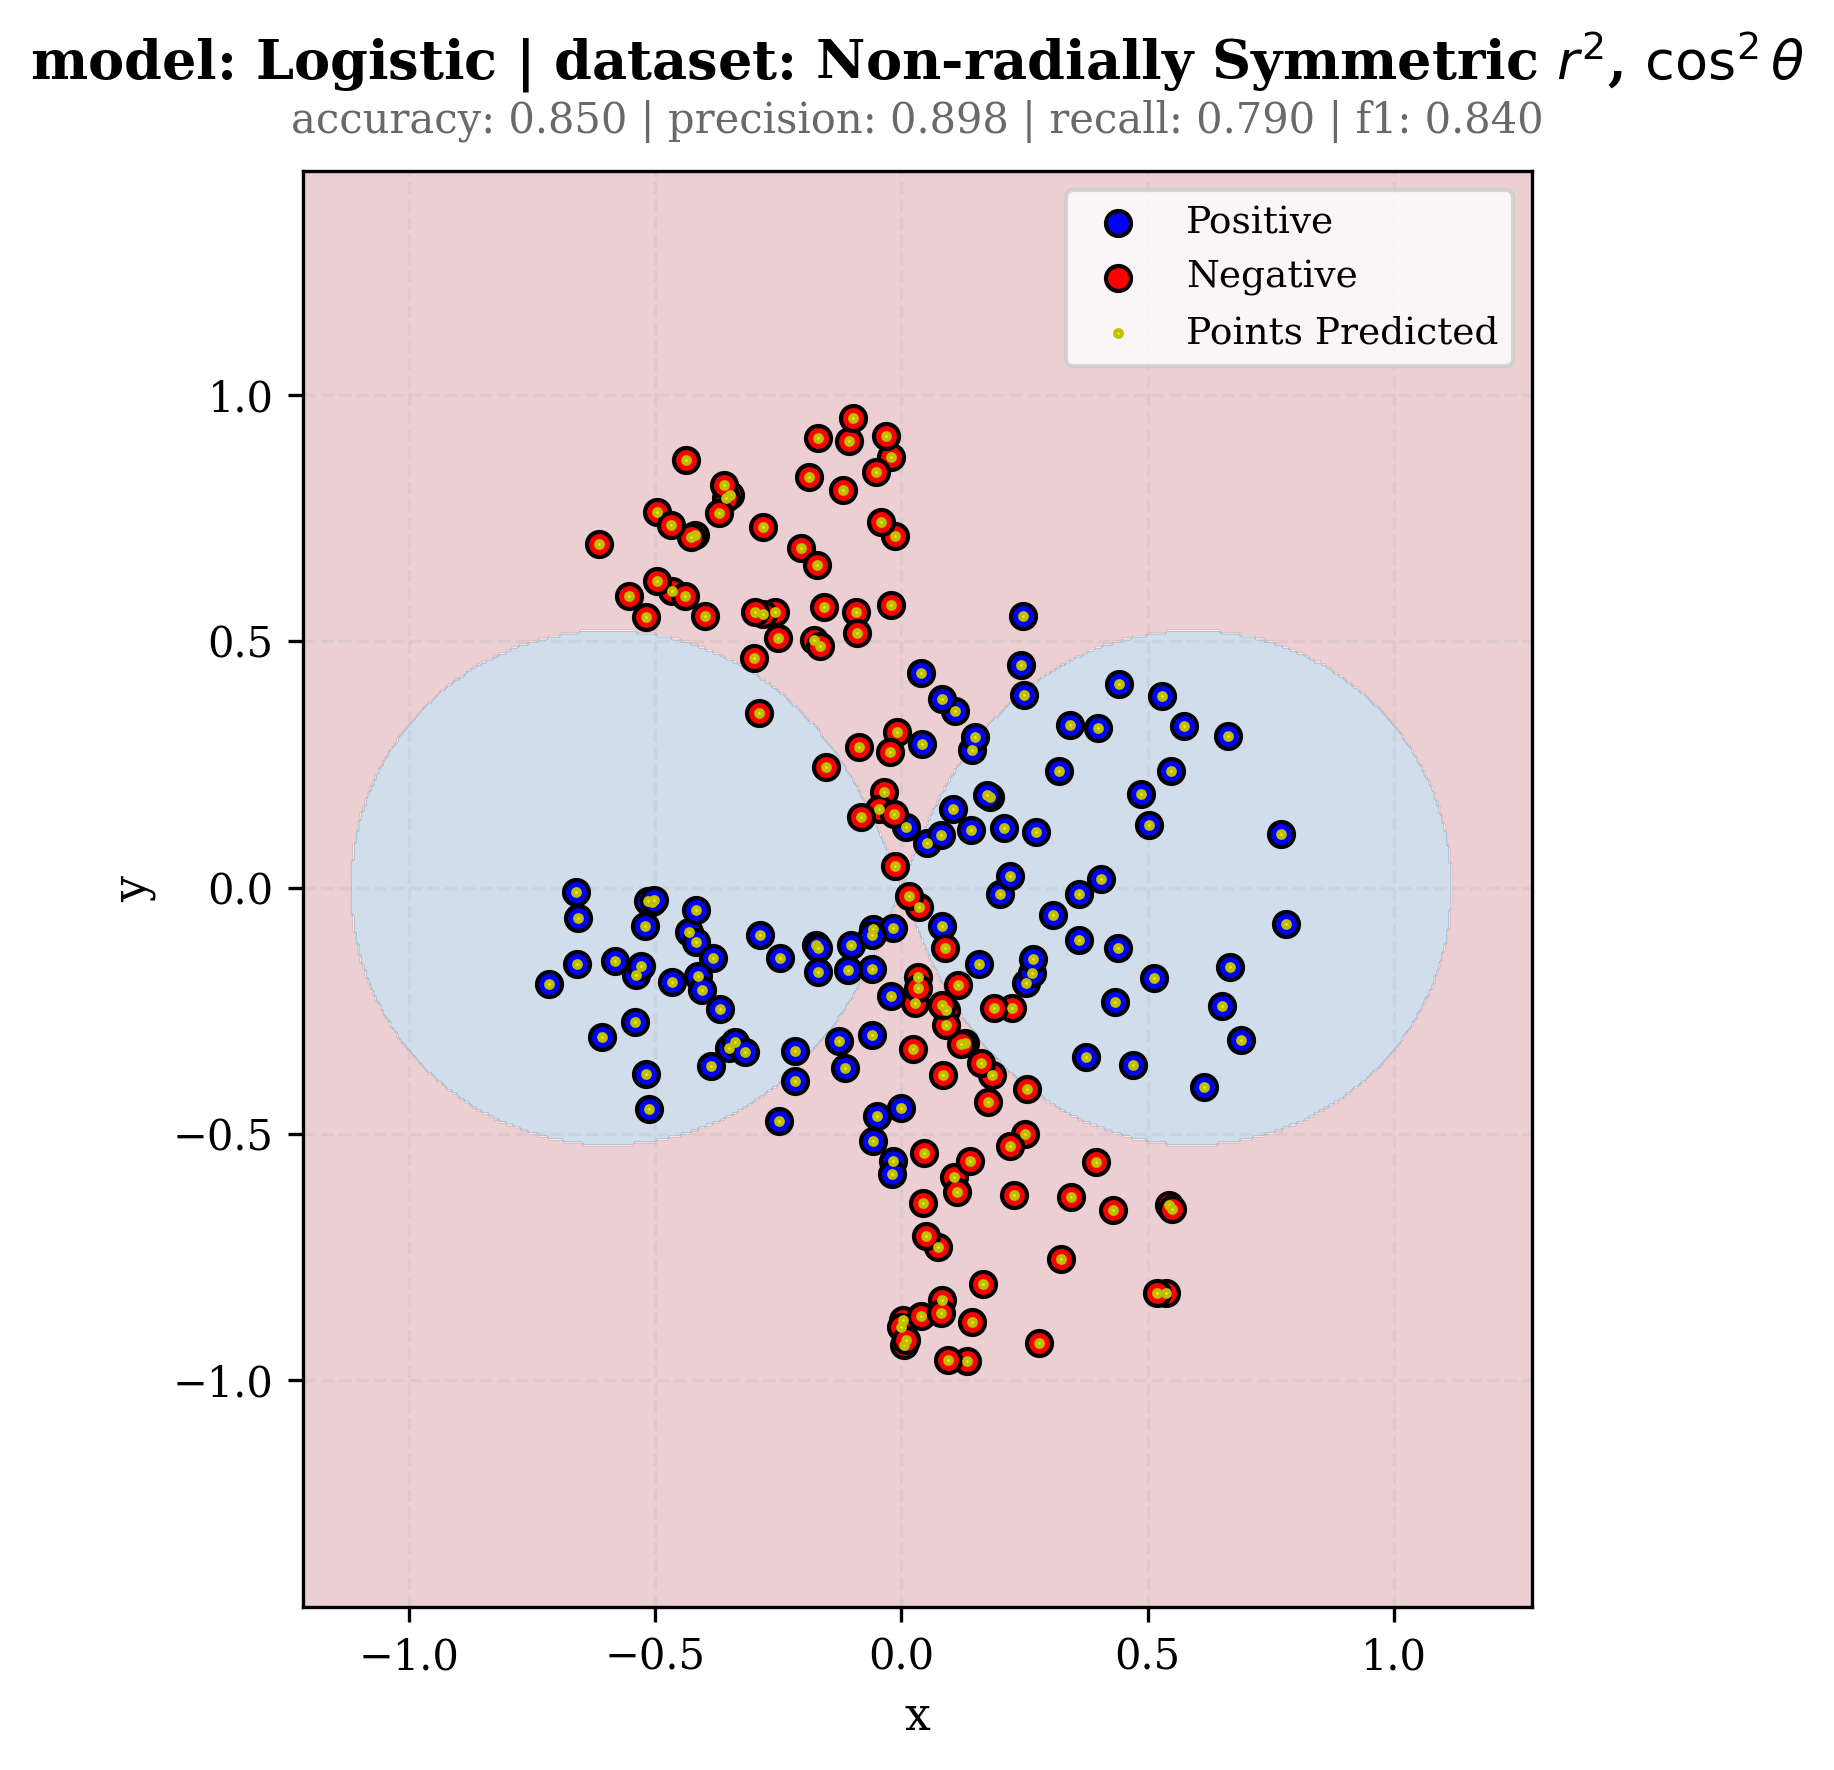

In [68]:
lr_model_r2cos2 = LogisticRegression(random_state=random_state)
lr_model_r2cos2.fit(synth_non_rad_r2cos2_dataset.X, synth_non_rad_r2cos2_dataset.y)
lr_metrics_r2cos2 = ModelMetrics('Logistic Regression', 'r^2,cos2()', synth_non_rad_r2cos2_dataset.y, lr_model_r2cos2.predict(synth_non_rad_r2cos2_dataset.X))
lr_metrics_r2cos2.compute_metrics()

dataset_label = r'$\cos^2{\theta}$'

lr_r2cos2_fig, lr_r2cos2_ax = plot_decision_boundary(
    model=lr_model_r2cos2, dataset_X=synth_non_rad_cartesian_dataset.X, dataset_y=synth_non_rad_cartesian_dataset.y,
    prediction_domain=grid_r2cos2_sqd, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Non-radially Symmetric $r^2$, {dataset_label}',
    metrics=lr_metrics_r2cos2.to_dict()
)

lr_r2cos2_ax.set_aspect('equal')
display(lr_r2cos2_fig)

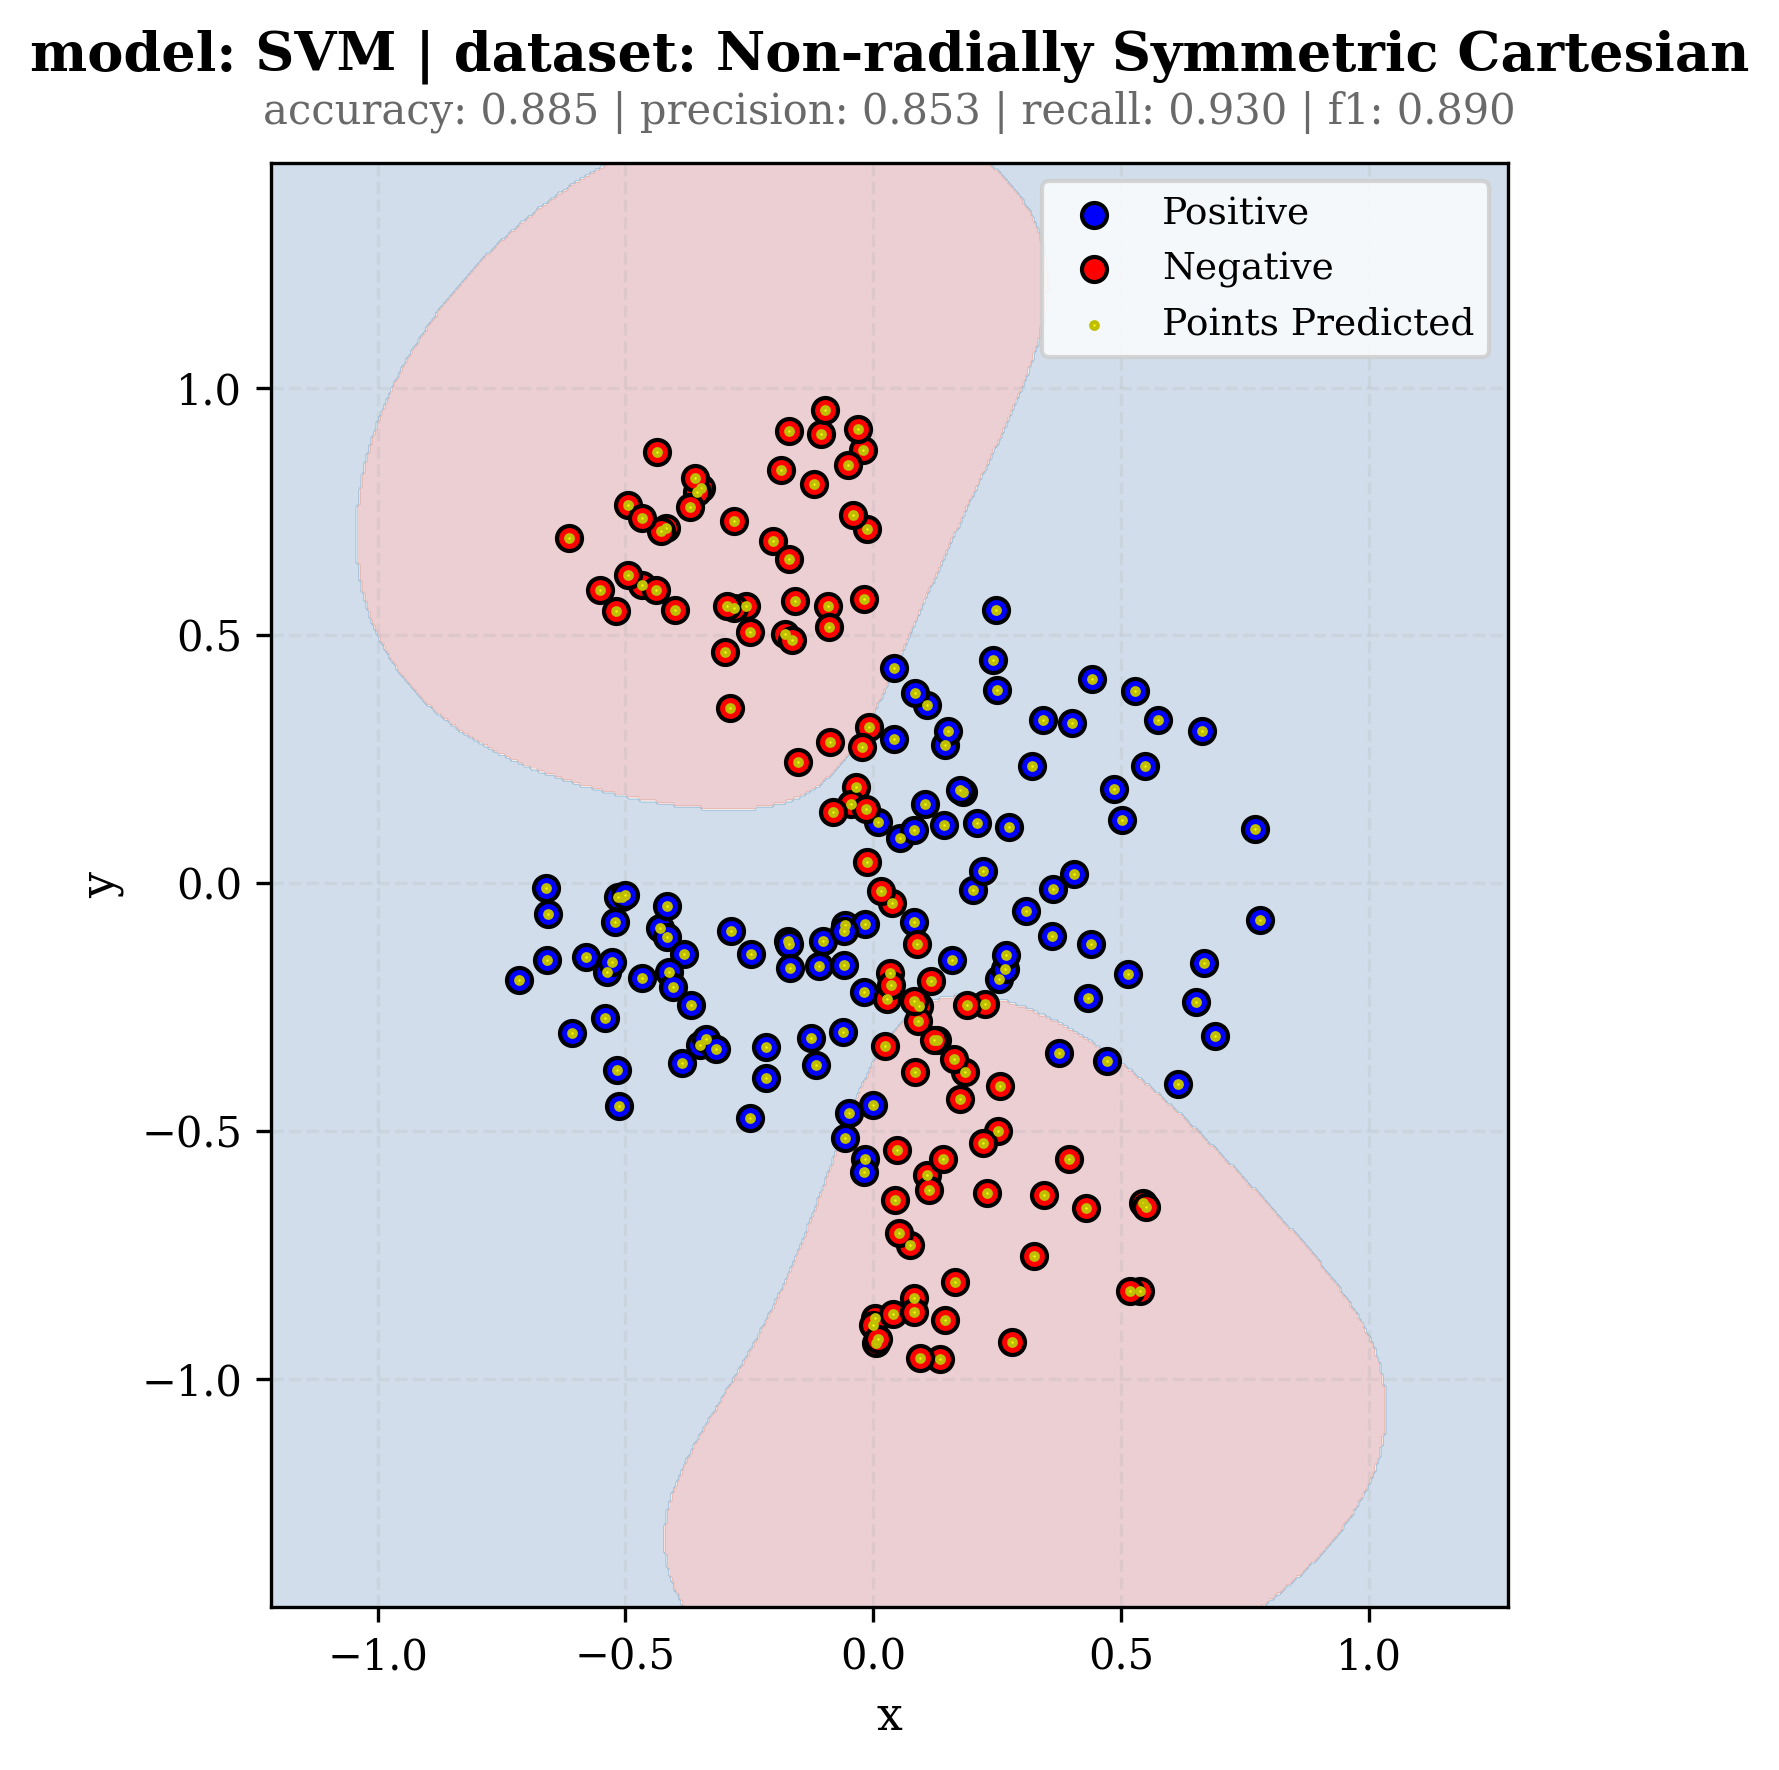

In [69]:
svm_model = SVC(kernel='rbf', random_state=random_state)
svm_model.fit(synth_non_rad_cartesian_dataset.X, synth_non_rad_cartesian_dataset.y)
svm_metrics = ModelMetrics('SVM', 'Cartesian', synth_non_rad_cartesian_dataset.y, svm_model.predict(synth_non_rad_cartesian_dataset.X))
svm_metrics.compute_metrics()

svm_fig, svm_ax = plot_decision_boundary(
    model=svm_model, dataset_X=synth_non_rad_cartesian_dataset.X, dataset_y=synth_non_rad_cartesian_dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Non-radially Symmetric Cartesian',
    metrics=svm_metrics.to_dict()
)

svm_ax.set_aspect('equal')
display(svm_fig)